# Mount HiRes Elevation Axis Tracking vs Atmospheric Seeing

## Overview
Analysis of the relationship between telescope elevation axis standard deviation (tracking error) and atmospheric seeing ellipticity over time.

This notebook examines temporal trends and correlations between:
- **Elevation Axis Stability**: RMS error in elevation (altitude) axis tracking
- **Seeing Ellipticity**: Atmospheric distortion measured by WFS systems

Multiple visualization approaches are presented to identify optimal data presentation methods.

In [1]:
# Section 1: Import Required Libraries
from datetime import datetime
from pathlib import Path

import numpy as np
import scipy
import pandas as pd
import matplotlib
matplotlib.use('agg')
from matplotlib import style
style.use('ggplot')
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

import sqlalchemy
from sqlalchemy import text
import pymysql
from pymysql.cursors import DictCursor

# For statistical analysis
from scipy import stats
from scipy.stats import linregress, gaussian_kde

# For FITS file handling (if needed)
try:
    from astropy.io import fits
    import astropy.units as u
except ImportError:
    print("astropy not available - will work with CSV/database only")

In [2]:
# Section 1b: Query Date Range Configuration
# Specify the start and end datetime for all data queries

from datetime import datetime, timedelta

# ============================================================================
# USER CONFIGURATION: REQUIRED - Set your query date range here
# ============================================================================
# Always supply explicit start and end datetimes
# Examples:
#   QUERY_START_DATE = datetime(2026, 1, 1)    # Jan 1, 2026
#   QUERY_END_DATE = datetime(2026, 3, 31)     # Mar 31, 2026
#
#   QUERY_START_DATE = datetime(2026, 3, 20)   # Mar 20, 2026
#   QUERY_END_DATE = datetime(2026, 3, 31)     # Mar 31, 2026

QUERY_START_DATE = datetime(2026, 1, 1)   # MODIFY THIS
QUERY_END_DATE = datetime(2026, 1, 15)    # MODIFY THIS

# ============================================================================
# Validate and display query date range
# ============================================================================

try:
    query_start_dt = QUERY_START_DATE
    query_end_dt = QUERY_END_DATE
    
    # Validate date range
    if query_start_dt >= query_end_dt:
        raise ValueError("QUERY_START_DATE must be before QUERY_END_DATE")
    
    duration_days = (query_end_dt - query_start_dt).days
    
    print("="*70)
    print("QUERY DATE RANGE CONFIGURATION")
    print("="*70)
    print(f"Start date: {query_start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"End date:   {query_end_dt.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Duration:   {duration_days} days")
    print("="*70)
    print("\nTo change the date range:")
    print("  - Modify QUERY_START_DATE and QUERY_END_DATE in Section 1b")
    print("  - Then re-run this cell and subsequent cells")
    print("="*70 + "\n")
    
except ValueError as e:
    print(f"ERROR in date configuration: {e}")
    print("Please fix QUERY_START_DATE and QUERY_END_DATE above")
    raise
except Exception as e:
    print(f"Error validating query date range: {e}")
    raise


QUERY DATE RANGE CONFIGURATION
Start date: 2026-01-01 00:00:00
End date:   2026-01-15 00:00:00
Duration:   14 days

To change the date range:
  - Modify QUERY_START_DATE and QUERY_END_DATE in Section 1b
  - Then re-run this cell and subsequent cells



In [3]:
# Section 2: Load and Prepare Data
# This section loads database connection for WFS seeing data from measurements database

# Database connection credentials
host_measurements = 'mariadb.mmto.arizona.edu'
db_measurements = 'measurements'
user_measurements = 'mmtstaff'
pwd_measurements = 'multiple'

try:
    # Create SQLAlchemy engine for measurements database (WFS seeing data)
    engine_bg = sqlalchemy.create_engine(
        f"mysql+pymysql://{user_measurements}:{pwd_measurements}@{host_measurements}/{db_measurements}"
    )
    
    print("✓ Database connection established for measurements database")
    print(f"  Host: {host_measurements}")
    print(f"  Database: {db_measurements}")
    
except Exception as e:
    print(f"Error establishing database connection: {e}")
    print("WFS seeing data queries will not be available")
    engine_bg = None


✓ Database connection established for measurements database
  Host: mariadb.mmto.arizona.edu
  Database: measurements


In [4]:
# Section 2b: Import query function from analyze_telescope_elevation_error module
# Add parent directory to path to import the module
import sys
from pathlib import Path

# Add the spie2026_alterr/stddev directory to path
stddev_module_path = Path('/Volumes/ExtremePro/git/spie2026_alterr/stddev')
if str(stddev_module_path) not in sys.path:
    sys.path.insert(0, str(stddev_module_path))

# Import the optimized query function
try:
    from analyze_telescope_elevation_error import query_telescope_alterr_data_optimized
    print("✓ Successfully imported query_telescope_alterr_data_optimized function")
except ImportError as e:
    print(f"Error importing query function: {e}")
    query_telescope_alterr_data_optimized = None


✓ Successfully imported query_telescope_alterr_data_optimized function


In [5]:
# Section 2c: Query telescope_alterr data from mount_hires database
# Uses the optimized query function with configurable date range from Section 1b

if query_telescope_alterr_data_optimized is not None:
    try:
        # Use date range configured in Section 1b
        print(f"Querying telescope_alterr data from {query_start_dt} to {query_end_dt}...")
        print("This data will be used as the elevation axis standard deviation metric")
        
        # Call the optimized query function with configured date range
        dates_alterr, rms_errors_alterr = query_telescope_alterr_data_optimized(
            host='mariadb.mmto.arizona.edu',
            user='mmtstaff',
            password='multiple',
            database='mount_hires',
            start_datetime=query_start_dt,
            end_datetime=query_end_dt
        )
        
        # Convert to DataFrame for easier analysis
        df_telescope_alterr = pd.DataFrame({
            'timestamp': dates_alterr,
            'telescope_alterr_arcsec': rms_errors_alterr * 3600.0  # Convert from degrees to arcsec
        })
        df_telescope_alterr['timestamp'] = pd.to_datetime(df_telescope_alterr['timestamp'])
        df_telescope_alterr.set_index('timestamp', inplace=True)
        
        print(f"\n✓ Retrieved {len(df_telescope_alterr)} telescope_alterr records")
        print(f"Actual data range: {df_telescope_alterr.index.min()} to {df_telescope_alterr.index.max()}")
        print(f"\nTelescope Elevation Error Statistics:")
        print(df_telescope_alterr['telescope_alterr_arcsec'].describe())
        
        # Calculate and display standard deviation
        std_alterr = df_telescope_alterr['telescope_alterr_arcsec'].std()
        mean_alterr = df_telescope_alterr['telescope_alterr_arcsec'].mean()
        
        print(f"\n{'='*60}")
        print(f"ELEVATION AXIS STANDARD DEVIATION:")
        print(f"  Mean telescope_alterr: {mean_alterr:.4f} arcsec")
        print(f"  Std Dev of alterr:     {std_alterr:.4f} arcsec")
        print(f"  Min/Max:               {df_telescope_alterr['telescope_alterr_arcsec'].min():.4f} / {df_telescope_alterr['telescope_alterr_arcsec'].max():.4f} arcsec")
        print(f"{'='*60}\n")
        
    except Exception as e:
        print(f"Error querying telescope_alterr data: {e}")
        import traceback
        traceback.print_exc()
        df_telescope_alterr = None
else:
    print("Query function not available")
    df_telescope_alterr = None


Querying telescope_alterr data from 2026-01-01 00:00:00 to 2026-01-15 00:00:00...
This data will be used as the elevation axis standard deviation metric
Connecting to mount_hires database at mariadb.mmto.arizona.edu...
Successfully connected to MariaDB database
No observing runs provided, querying entire date range...
Querying data from 2026-01-01 00:00:00 to 2026-01-15 00:00:00
SQL Query: SELECT timestamp, telescope_alterr 
            FROM rd_data_vu 
            WHERE timestamp >= %s AND timestamp <= %s
            AND modealt = 'tracking' AND modeaz = 'tracking' AND moderot = 'tracking'
            AND ABS(telescope_alterr) <= %s
            ORDER BY timestamp ASC
Parameters: start_timestamp_us=1767250800000000, end_timestamp_us=1768460400000000, threshold=0.001389 degrees (5.0 arcsec)
Retrieved total 4272802 records from database
After filtering: 4272802 valid records

✓ Retrieved 4272802 telescope_alterr records
Actual data range: 2026-01-03 02:28:11.692329 to 2026-01-15 06:57:01

In [6]:
# Section 3: Calculate Standard Deviation over 2-minute intervals
# Resample the raw telescope_alterr data into 2-minute bins and calculate stddev for each bin

if df_telescope_alterr is not None and len(df_telescope_alterr) > 0:
    try:
        print("Calculating standard deviation over 2-minute intervals...")
        
        # Resample to 2-minute intervals and calculate standard deviation
        df_alterr_2min = df_telescope_alterr['telescope_alterr_arcsec'].resample('2min').agg(['std', 'mean', 'min', 'max', 'count'])
        df_alterr_2min.columns = ['std', 'mean', 'min', 'max', 'count']
        
        # Remove bins with fewer than 5 samples (incomplete 2-minute intervals)
        df_alterr_2min_clean = df_alterr_2min[df_alterr_2min['count'] >= 5].copy()
        
        print(f"\n✓ Resampled to 2-minute intervals: {len(df_alterr_2min)} total bins")
        print(f"  Valid bins (count >= 5): {len(df_alterr_2min_clean)}")
        print(f"\n2-Minute Interval Statistics (Standard Deviation):")
        print(df_alterr_2min_clean['std'].describe())
        
        # Calculate overall statistics
        overall_stddev_mean = df_alterr_2min_clean['std'].mean()
        overall_stddev_std = df_alterr_2min_clean['std'].std()
        overall_stddev_min = df_alterr_2min_clean['std'].min()
        overall_stddev_max = df_alterr_2min_clean['std'].max()
        
        print(f"\n{'='*60}")
        print(f"ELEVATION AXIS STANDARD DEVIATION (2-MIN RESAMPLED):")
        print(f"  Mean of 2-min stddevs:  {overall_stddev_mean:.4f} arcsec")
        print(f"  Std Dev of stddevs:     {overall_stddev_std:.4f} arcsec")
        print(f"  Min/Max stddev:         {overall_stddev_min:.4f} / {overall_stddev_max:.4f} arcsec")
        print(f"  Number of 2-min bins:   {len(df_alterr_2min_clean)}")
        print(f"{'='*60}\n")
        
        # Display first few bins
        print("First 10 two-minute intervals:")
        print(df_alterr_2min_clean.head(10))
        
    except Exception as e:
        print(f"Error calculating 2-minute stddev: {e}")
        import traceback
        traceback.print_exc()
        df_alterr_2min_clean = None
else:
    print("No telescope_alterr data available for stddev calculation")
    df_alterr_2min_clean = None


Calculating standard deviation over 2-minute intervals...

✓ Resampled to 2-minute intervals: 8775 total bins
  Valid bins (count >= 5): 710

2-Minute Interval Statistics (Standard Deviation):
count    710.000000
mean       0.120523
std        0.091913
min        0.023289
25%        0.059324
50%        0.076591
75%        0.170838
max        0.515290
Name: std, dtype: float64

ELEVATION AXIS STANDARD DEVIATION (2-MIN RESAMPLED):
  Mean of 2-min stddevs:  0.1205 arcsec
  Std Dev of stddevs:     0.0919 arcsec
  Min/Max stddev:         0.0233 / 0.5153 arcsec
  Number of 2-min bins:   710

First 10 two-minute intervals:
                          std      mean       min       max  count
timestamp                                                         
2026-01-03 02:28:00  0.093348  0.686199  0.311459  1.049232  10831
2026-01-03 02:30:00  0.113246  0.702598  0.430956  1.109057   1169
2026-01-03 02:34:00  0.079396  0.642388  0.346724  0.895465   5758
2026-01-03 02:36:00  0.069366  0.631586  

In [7]:
# Section 4: Query WFS seeing data
# WFS seeing measurements from various instruments
# Uses the date range configured in Section 1b

try:
    if engine_bg is None:
        raise NameError("Database connection not available")
    
    # Use the user-configured date range from Section 1b
    query_start_ms = int(query_start_dt.timestamp() * 1000)
    query_end_ms = int(query_end_dt.timestamp() * 1000)
    print(f"Querying seeing data for range: {query_start_dt} to {query_end_dt}")
    
    query_seeing = f"""
    SELECT 
        timestamp,
        FROM_UNIXTIME(timestamp/1000) as time_mst,
        value as seeing_arcsec
    FROM measurements.wfs_seeing
    WHERE timestamp >= {query_start_ms} AND timestamp <= {query_end_ms}
    AND value > 0.2 AND value < 3.0
    ORDER BY timestamp
    """
    
    df_seeing = pd.read_sql(query_seeing, engine_bg)
    if len(df_seeing) > 0:
        df_seeing['time_mst'] = pd.to_datetime(df_seeing['time_mst'])
        df_seeing.set_index('time_mst', inplace=True)
        
        print(f"\n✓ Loaded {len(df_seeing)} WFS seeing measurements")
        print(f"  Date range: {df_seeing.index.min()} to {df_seeing.index.max()}")
        print(f"\nWFS Seeing Summary:")
        print(df_seeing.describe())
    else:
        print("No WFS seeing data found in date range")
        df_seeing = None
    
except NameError as e:
    print(f"Skipping WFS seeing query: {e}")
    df_seeing = None
except Exception as e:
    print(f"Error loading seeing data: {e}")
    import traceback
    traceback.print_exc()
    df_seeing = None


Querying seeing data for range: 2026-01-01 00:00:00 to 2026-01-15 00:00:00

✓ Loaded 3651 WFS seeing measurements
  Date range: 2026-01-02 19:41:03 to 2026-01-14 23:59:39

WFS Seeing Summary:
          timestamp  seeing_arcsec
count  3.651000e+03    3651.000000
mean   1.768015e+12       1.134139
std    3.850063e+08       0.244106
min    1.767408e+12       0.580000
25%    1.767613e+12       0.950000
50%    1.768278e+12       1.110000
75%    1.768361e+12       1.310000
max    1.768460e+12       2.050000


In [8]:
# Section 5: Query Seeing Ellipticity
# Seeing ellipticity data from WFS spot analysis
# Uses the date range configured in Section 1b

try:
    if engine_bg is None:
        raise NameError("Database connection not available")
    
    # Use the user-configured date range from Section 1b
    query_start_ms = int(query_start_dt.timestamp() * 1000)
    query_end_ms = int(query_end_dt.timestamp() * 1000)
    
    # Query seeing ellipticity from measurements.wfs_ellipticity table
    query_ellip = f"""
    SELECT 
        timestamp,
        FROM_UNIXTIME(timestamp/1000) as time_mst,
        value as ellipticity
    FROM measurements.wfs_ellipticity
    WHERE timestamp >= {query_start_ms} AND timestamp <= {query_end_ms}
    ORDER BY timestamp
    """
    
    df_ellipticity = pd.read_sql(query_ellip, engine_bg)
    if len(df_ellipticity) > 0:
        df_ellipticity['time_mst'] = pd.to_datetime(df_ellipticity['time_mst'])
        df_ellipticity.set_index('time_mst', inplace=True)
        
        print(f"\n✓ Loaded {len(df_ellipticity)} WFS spot ellipticity measurements")
        print(f"  Date range: {df_ellipticity.index.min()} to {df_ellipticity.index.max()}")
        print(f"\nWFS Seeing Ellipticity Summary:")
        print(df_ellipticity['ellipticity'].describe())
    else:
        print("No WFS ellipticity data found in date range")
        df_ellipticity = None
        
except NameError as e:
    print(f"Skipping seeing ellipticity query: {e}")
    df_ellipticity = None
except Exception as e:
    print(f"Error loading seeing ellipticity data: {e}")
    import traceback
    traceback.print_exc()
    df_ellipticity = None



✓ Loaded 3651 WFS spot ellipticity measurements
  Date range: 2026-01-02 19:41:03 to 2026-01-14 23:59:39

WFS Seeing Ellipticity Summary:
count    3651.000000
mean        0.108317
std         0.066236
min         0.001000
25%         0.059000
50%         0.101000
75%         0.145000
max         0.692000
Name: ellipticity, dtype: float64


In [9]:
# Section 6: Use 2-minute resampled elevation data (from Section 3)
# Extract standard deviation metrics from already-calculated 2-minute bins

print("Using 2-minute resampled elevation data from Section 3...")

if df_alterr_2min_clean is not None and len(df_alterr_2min_clean) > 0:
    # Extract statistics from 2-minute bins
    df_alt_std = df_alterr_2min_clean[['std', 'mean', 'min', 'max', 'count']].copy()
    df_alt_std.columns = ['altitude_std', 'altitude_mean', 'altitude_min', 'altitude_max', 'sample_count']
    
    print(f"\nElevation Axis Tracking Statistics (2-Minute Bins):")
    print(f"  Standard Deviation - Min: {df_alt_std['altitude_std'].min():.3f}\", Max: {df_alt_std['altitude_std'].max():.3f}\"")
    print(f"  Mean Error - Min: {df_alt_std['altitude_mean'].min():.3f}\", Max: {df_alt_std['altitude_mean'].max():.3f}\"")
    
    # Use standard deviation as the tracking error metric
    tracking_error_metric = 'altitude_std'  # Standard deviation from 2-min resampling
    
    print(f"\nUsing '{tracking_error_metric}' as elevation tracking error metric")
    print(f"Bins: {len(df_alt_std)}")
else:
    print("No 2-minute resampled elevation data available")
    print("Please run Section 3 first to calculate 2-minute standard deviations")
    df_alt_std = None


Using 2-minute resampled elevation data from Section 3...

Elevation Axis Tracking Statistics (2-Minute Bins):
  Standard Deviation - Min: 0.023", Max: 0.515"
  Mean Error - Min: -1.313", Max: 1.288"

Using 'altitude_std' as elevation tracking error metric
Bins: 710


In [28]:
# Section 7: Resample Data by Time Period
# Resample to daily, weekly, monthly bins to correlate elevation tracking and seeing

def resample_data_combined(df_alt, df_ellipticity, resample_period='D'):
    """
    Resample altitude tracking error and ellipticity to specified period
    
    Parameters:
    - df_alt: DataFrame with altitude_std column (2-minute bins)
    - df_ellipticity: DataFrame with ellipticity column
    - resample_period: 'D' (daily), 'W' (weekly), 'MS' (monthly start)
    """
    
    # Prepare altitude data (use altitude_std from 2-minute bins)
    if df_alt is not None and len(df_alt) > 0:
        df_alt_resampled = df_alt[['altitude_std']].resample(resample_period).agg({
            'altitude_std': ['mean', 'std', 'min', 'max', 'count']
        })
        df_alt_resampled.columns = ['alt_std_mean', 'alt_std_std', 'alt_std_min', 'alt_std_max', 'alt_count']
    else:
        df_alt_resampled = None
    
    # Prepare ellipticity data
    if df_ellipticity is not None and len(df_ellipticity) > 0:
        if 'ellipticity' in df_ellipticity.columns:
            df_ellip_resampled = df_ellipticity[['ellipticity']].resample(resample_period).agg({
                'ellipticity': ['mean', 'std', 'min', 'max', 'count']
            })
            df_ellip_resampled.columns = ['ellip_mean', 'ellip_std', 'ellip_min', 'ellip_max', 'ellip_count']
        else:
            df_ellip_resampled = None
    else:
        df_ellip_resampled = None
    
    # Combine into single dataframe
    if df_alt_resampled is not None and df_ellip_resampled is not None:
        df_combined_resampled = pd.concat([df_alt_resampled, df_ellip_resampled], axis=1, sort=True)
        # Remove rows with insufficient data
        df_combined_resampled = df_combined_resampled[(df_combined_resampled['alt_count'] >= 5) & 
                                                       (df_combined_resampled['ellip_count'] >= 5)]
    elif df_alt_resampled is not None:
        df_combined_resampled = df_alt_resampled
    else:
        df_combined_resampled = None
    
    return df_combined_resampled

# Create resampled datasets
if df_alt_std is not None and df_ellipticity is not None:
    print("Resampling elevation tracking error and seeing ellipticity to daily/weekly/monthly periods...")
    df_daily = resample_data_combined(df_alt_std, df_ellipticity, 'D')
    df_weekly = resample_data_combined(df_alt_std, df_ellipticity, 'W')
    df_monthly = resample_data_combined(df_alt_std, df_ellipticity, 'MS')
    
    print(f"\nResampled data points:")
    print(f"  Daily: {len(df_daily) if df_daily is not None else 0}")
    print(f"  Weekly: {len(df_weekly) if df_weekly is not None else 0}")
    print(f"  Monthly: {len(df_monthly) if df_monthly is not None else 0}")
    
    if df_daily is not None and len(df_daily) > 0:
        print(f"\nDaily data summary:")
        print(df_daily.head())
else:
    print("Insufficient data for resampling")
    print(f"  df_alt_std available: {df_alt_std is not None}")
    print(f"  df_ellipticity available: {df_ellipticity is not None}")
    df_daily = None
    df_weekly = None
    df_monthly = None


Resampling elevation tracking error and seeing ellipticity to daily/weekly/monthly periods...

Resampled data points:
  Daily: 5
  Weekly: 3
  Monthly: 1

Daily data summary:
            alt_std_mean  alt_std_std  alt_std_min  alt_std_max  alt_count  \
2026-01-03      0.154950     0.093414     0.039506     0.511991      145.0   
2026-01-05      0.189785     0.100276     0.045050     0.437899      102.0   
2026-01-06      0.156740     0.088956     0.041672     0.412440       96.0   
2026-01-13      0.074019     0.062281     0.023289     0.375738      149.0   
2026-01-14      0.074212     0.064046     0.025237     0.515290      152.0   

            ellip_mean  ellip_std  ellip_min  ellip_max  ellip_count  
2026-01-03    0.081860   0.069348      0.010      0.692        279.0  
2026-01-05    0.085061   0.070785      0.001      0.493        819.0  
2026-01-06    0.145524   0.051994      0.031      0.311        166.0  
2026-01-13    0.126616   0.060227      0.007      0.494        991.0  
2

In [29]:
# Section 6 (UPDATED): Create Scatter Plot - Elevation Std Dev vs Seeing Ellipticity
# Generate scatter plot comparing elevation tracking error to seeing ellipticity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create scatter plots for daily and weekly data
resample_sets = [('Daily', df_daily), ('Weekly', df_weekly)]

for idx, (label, df) in enumerate(resample_sets):
    if df is not None and len(df) > 0:
        ax = axes[idx]
        
        # Extract data using ellipticity columns
        x = df['ellip_mean'].values
        y = df['alt_std_mean'].values
        
        # Remove NaN values
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 2:
            # Calculate correlation
            correlation = np.corrcoef(x, y)[0, 1]
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = slope * line_x + intercept
            
            # Scatter plot with error bars
            ax.errorbar(x, y, 
                       xerr=df['ellip_std'].values[mask],
                       yerr=df['alt_std_std'].values[mask],
                       fmt='o', alpha=0.6, markersize=8, capsize=5, 
                       elinewidth=1.5, capthick=1.5, label='Data with 1σ')
            ax.plot(line_x, line_y, 'r--', linewidth=2.5, label=f'Linear fit (R²={r_value**2:.3f})')
            
            # Labels and title
            ax.set_xlabel('Seeing Ellipticity', fontsize=11, fontweight='bold')
            ax.set_ylabel('Elevation Axis Std Dev (arcsec)', fontsize=11, fontweight='bold')
            ax.set_title(f'{label} Data (n={len(x)})\nr={correlation:.3f}, p={p_value:.2e}', 
                        fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=10)
            
            # Print statistics
            print(f"\n{label} Scatter Statistics:")
            print(f"  Points: {len(x)}")
            print(f"  Correlation coefficient: {correlation:.4f}")
            print(f"  Slope: {slope:.4f} arcsec/ellipticity")
            print(f"  Intercept: {intercept:.4f} arcsec")
            print(f"  R-squared: {r_value**2:.4f}")
            print(f"  P-value: {p_value:.2e}")
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})', 
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data available', 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('scatter_alt_vs_ellipticity.png', dpi=300, bbox_inches='tight')
plt.close()

print("\n✓ Scatter plot (ellipticity) saved as 'scatter_alt_vs_ellipticity.png'")



Daily Scatter Statistics:
  Points: 5
  Correlation coefficient: -0.2019
  Slope: -0.3777 arcsec/ellipticity
  Intercept: 0.1701 arcsec
  R-squared: 0.0408
  P-value: 7.45e-01

Weekly Scatter Statistics:
  Points: 3
  Correlation coefficient: -0.7991
  Slope: -1.5750 arcsec/ellipticity
  Intercept: 0.2887 arcsec
  R-squared: 0.6386
  P-value: 4.11e-01

✓ Scatter plot (ellipticity) saved as 'scatter_alt_vs_ellipticity.png'



SCATTER PLOT: Elevation Std Dev vs Seeing Ellipticity


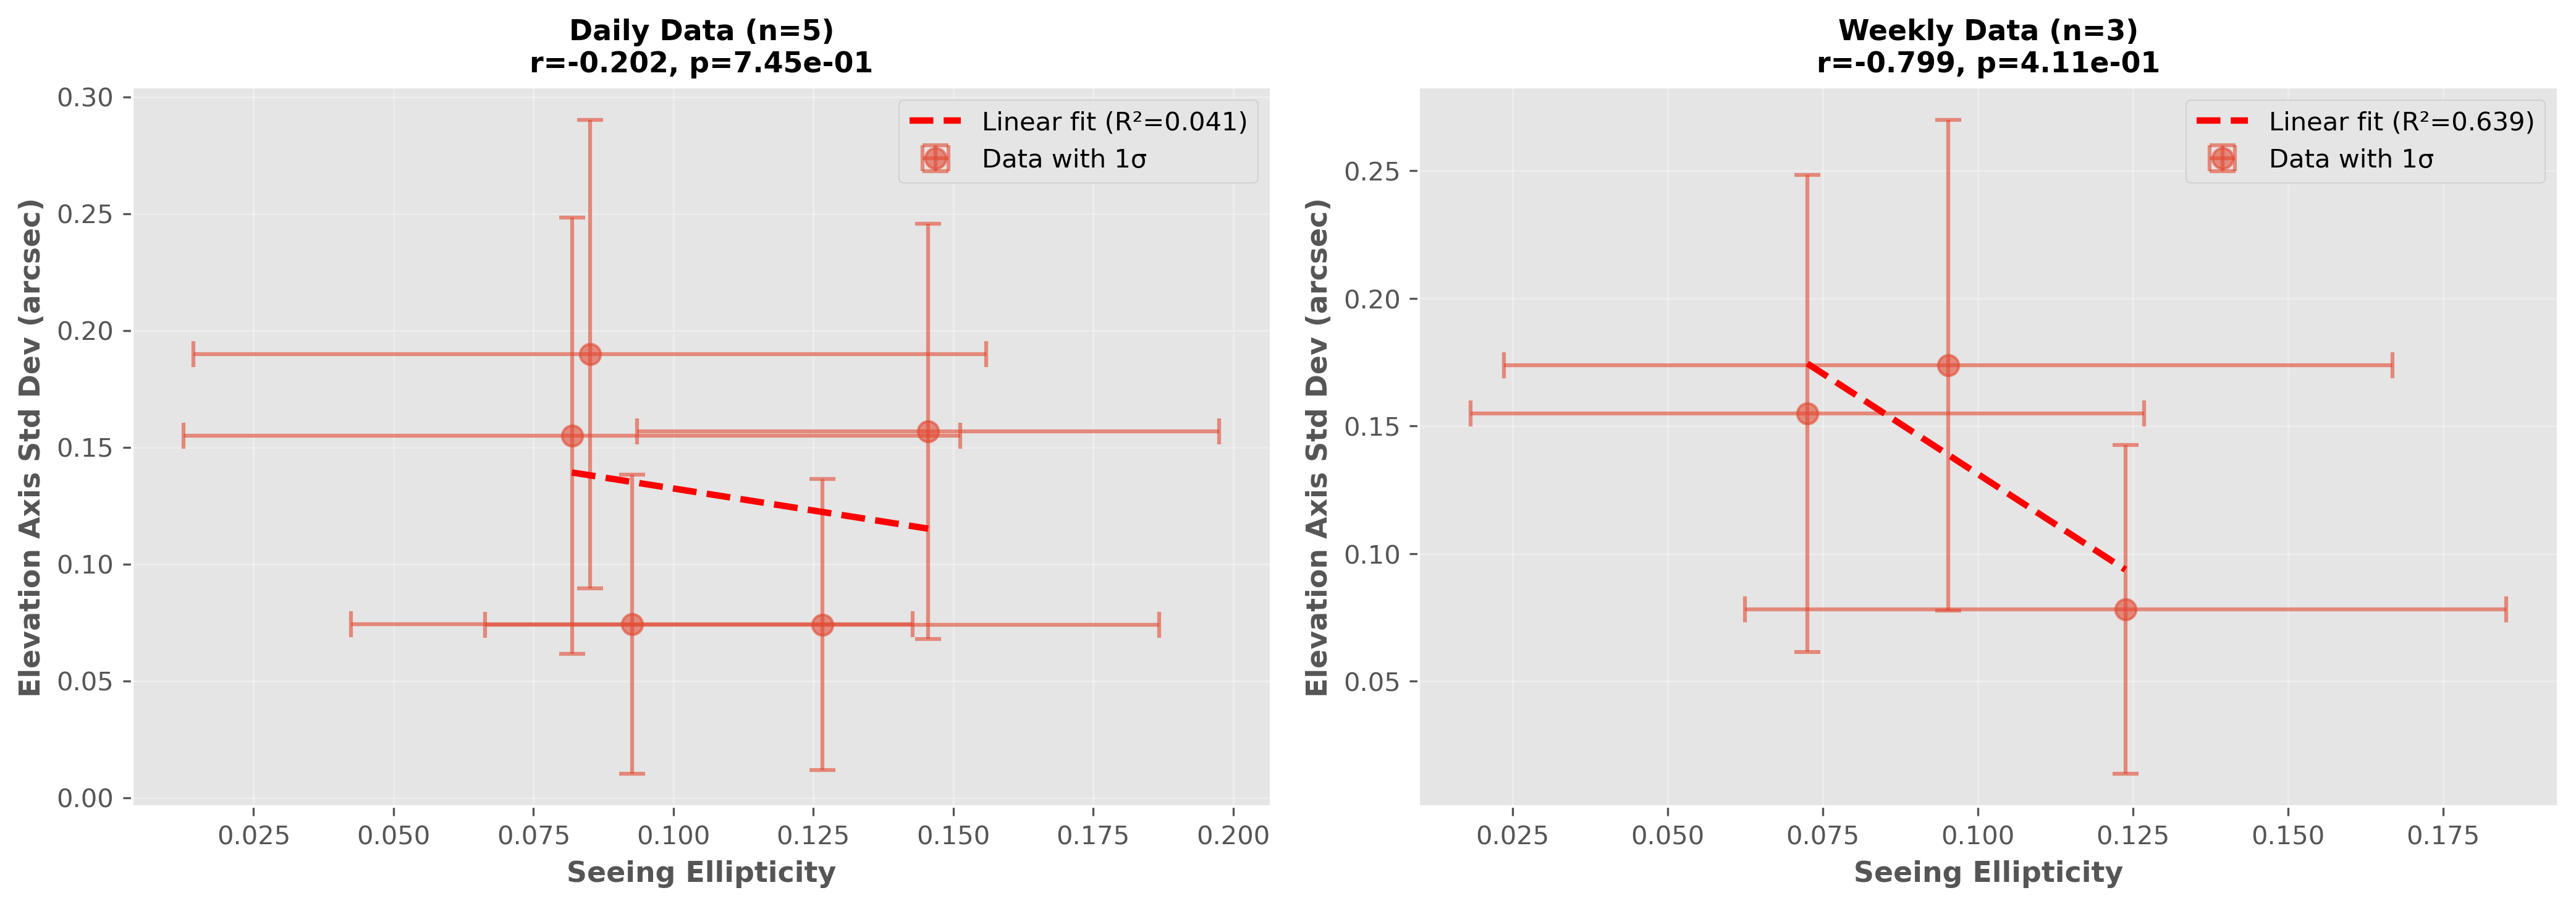

In [30]:
# Section 6a: Display scatter plot
from IPython.display import Image, display

print("\n" + "="*60)
print("SCATTER PLOT: Elevation Std Dev vs Seeing Ellipticity")
print("="*60)
display(Image(filename='scatter_alt_vs_ellipticity.png'))


In [31]:
# Section 7 (UPDATED): Generate Time Series - Elevation Std Dev vs Seeing Ellipticity
# Create dual-axis time series plots with elevation tracking error and seeing ellipticity

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily time series with dual axes
if df_daily is not None and len(df_daily) > 0:
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Plot elevation std on left axis
    line1 = ax1.plot(df_daily.index, df_daily['alt_std_mean'], 'b-o', linewidth=2.5, markersize=8, label='Elevation Std Dev')
    ax1.fill_between(df_daily.index, 
                      df_daily['alt_std_mean'] - df_daily['alt_std_std'],
                      df_daily['alt_std_mean'] + df_daily['alt_std_std'],
                      alpha=0.2, color='blue')
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold', color='b')
    ax1.tick_params(axis='y', labelcolor='b', labelsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot ellipticity on right axis
    if 'ellip_mean' in df_daily.columns:
        line2 = ax1_twin.plot(df_daily.index, df_daily['ellip_mean'], 'r-s', linewidth=2.5, markersize=8, label='Seeing Ellipticity')
        ax1_twin.fill_between(df_daily.index,
                             df_daily['ellip_mean'] - df_daily['ellip_std'],
                             df_daily['ellip_mean'] + df_daily['ellip_std'],
                             alpha=0.2, color='red')
        ax1_twin.set_ylabel('Seeing Ellipticity', fontsize=12, fontweight='bold', color='r')
        ax1_twin.tick_params(axis='y', labelcolor='r', labelsize=10)
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1_twin.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    
    ax1.set_title(f'Daily Trends (n={len(df_daily)} days)', fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No daily data available', ha='center', va='center', transform=axes[0].transAxes, fontsize=11)

# Weekly time series
if df_weekly is not None and len(df_weekly) > 0:
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    line1 = ax2.plot(df_weekly.index, df_weekly['alt_std_mean'], 'b-o', linewidth=2.5, markersize=10, label='Elevation Std Dev')
    ax2.fill_between(df_weekly.index,
                     df_weekly['alt_std_mean'] - df_weekly['alt_std_std'],
                     df_weekly['alt_std_mean'] + df_weekly['alt_std_std'],
                     alpha=0.2, color='blue')
    ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold', color='b')
    ax2.tick_params(axis='y', labelcolor='b', labelsize=10)
    ax2.grid(True, alpha=0.3)
    
    if 'ellip_mean' in df_weekly.columns:
        line2 = ax2_twin.plot(df_weekly.index, df_weekly['ellip_mean'], 'r-s', linewidth=2.5, markersize=10, label='Seeing Ellipticity')
        ax2_twin.fill_between(df_weekly.index,
                             df_weekly['ellip_mean'] - df_weekly['ellip_std'],
                             df_weekly['ellip_mean'] + df_weekly['ellip_std'],
                             alpha=0.2, color='red')
        ax2_twin.set_ylabel('Seeing Ellipticity', fontsize=12, fontweight='bold', color='r')
        ax2_twin.tick_params(axis='y', labelcolor='r', labelsize=10)
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    
    ax2.set_title(f'Weekly Trends (n={len(df_weekly)} weeks)', fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No weekly data available', ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('timeseries_alt_vs_ellipticity.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Time series plot (ellipticity) saved as 'timeseries_alt_vs_ellipticity.png'")


✓ Time series plot (ellipticity) saved as 'timeseries_alt_vs_ellipticity.png'


In [34]:
# Section 8 (UPDATED): Generate Hexbin Density Plot - Elevation Std Dev vs Seeing Ellipticity

fig, ax = plt.subplots(figsize=(12, 9))

if df_daily is not None and len(df_daily) > 1:
    x = df_daily['ellip_mean'].values
    y = df_daily['alt_std_mean'].values
    
    hexbin = ax.hexbin(x, y, gridsize=8, cmap='YlOrRd', mincnt=1, edgecolors='black', linewidths=0.2)
    
    # Add colorbar
    cbar = plt.colorbar(hexbin, ax=ax)
    cbar.set_label('Frequency', fontsize=11, fontweight='bold')
    
    # Add regression line
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2.5, label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}', alpha=0.8)
        
        # Calculate R-squared
        y_pred = p(x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', transform=ax.transAxes, fontsize=11,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Seeing Ellipticity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold')
    ax.set_title(f'Hexbin Density: Elevation vs Ellipticity (Daily data, n={len(df_daily)})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
else:
    ax.text(0.5, 0.5, 'Insufficient data for hexbin plot', ha='center', va='center', 
           transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig('hexbin_alt_vs_ellipticity.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Hexbin density plot (ellipticity) saved as 'hexbin_alt_vs_ellipticity.png'")


✓ Hexbin density plot (ellipticity) saved as 'hexbin_alt_vs_ellipticity.png'


In [36]:
# Section 9 (UPDATED): Generate 2D KDE Density Plot - Elevation Std Dev vs Seeing Ellipticity

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 9))

if df_daily is not None and len(df_daily) > 1:
    x = df_daily['ellip_mean'].values
    y = df_daily['alt_std_mean'].values
    
    # Calculate 2D KDE
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    
    # Sort by density so densest points plot last
    idx = z.argsort()
    x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]
    
    scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=100, cmap='viridis', 
                        alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Kernel Density Estimate', fontsize=11, fontweight='bold')
    
    # Add contour lines
    x_range = np.linspace(x.min(), x.max(), 100)
    y_range = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_range, y_range)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = gaussian_kde(xy)(positions).reshape(X.shape)
    
    contours = ax.contour(X, Y, Z, levels=4, colors='gray', alpha=0.4, linewidths=1.5)
    ax.clabel(contours, inline=True, fontsize=8)
    
    # Add regression line
    if len(x) > 1:
        z_fit = np.polyfit(x, y, 1)
        p = np.poly1d(z_fit)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=3, label=f'Linear fit: y={z_fit[0]:.3f}x+{z_fit[1]:.3f}', alpha=0.8)
        
        # Calculate R-squared
        y_pred = p(x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', transform=ax.transAxes, fontsize=11,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Seeing Ellipticity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold')
    ax.set_title(f'2D KDE Density: Elevation vs Ellipticity (Daily data, n={len(df_daily)})', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
else:
    ax.text(0.5, 0.5, 'Insufficient data for KDE plot', ha='center', va='center',
           transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig('kde_alt_vs_ellipticity.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ 2D KDE density plot (ellipticity) saved as 'kde_alt_vs_ellipticity.png'")


✓ 2D KDE density plot (ellipticity) saved as 'kde_alt_vs_ellipticity.png'


## Section 7a: Time Series Visualization
**Daily and Weekly trends of elevation tracking error vs seeing ellipticity**

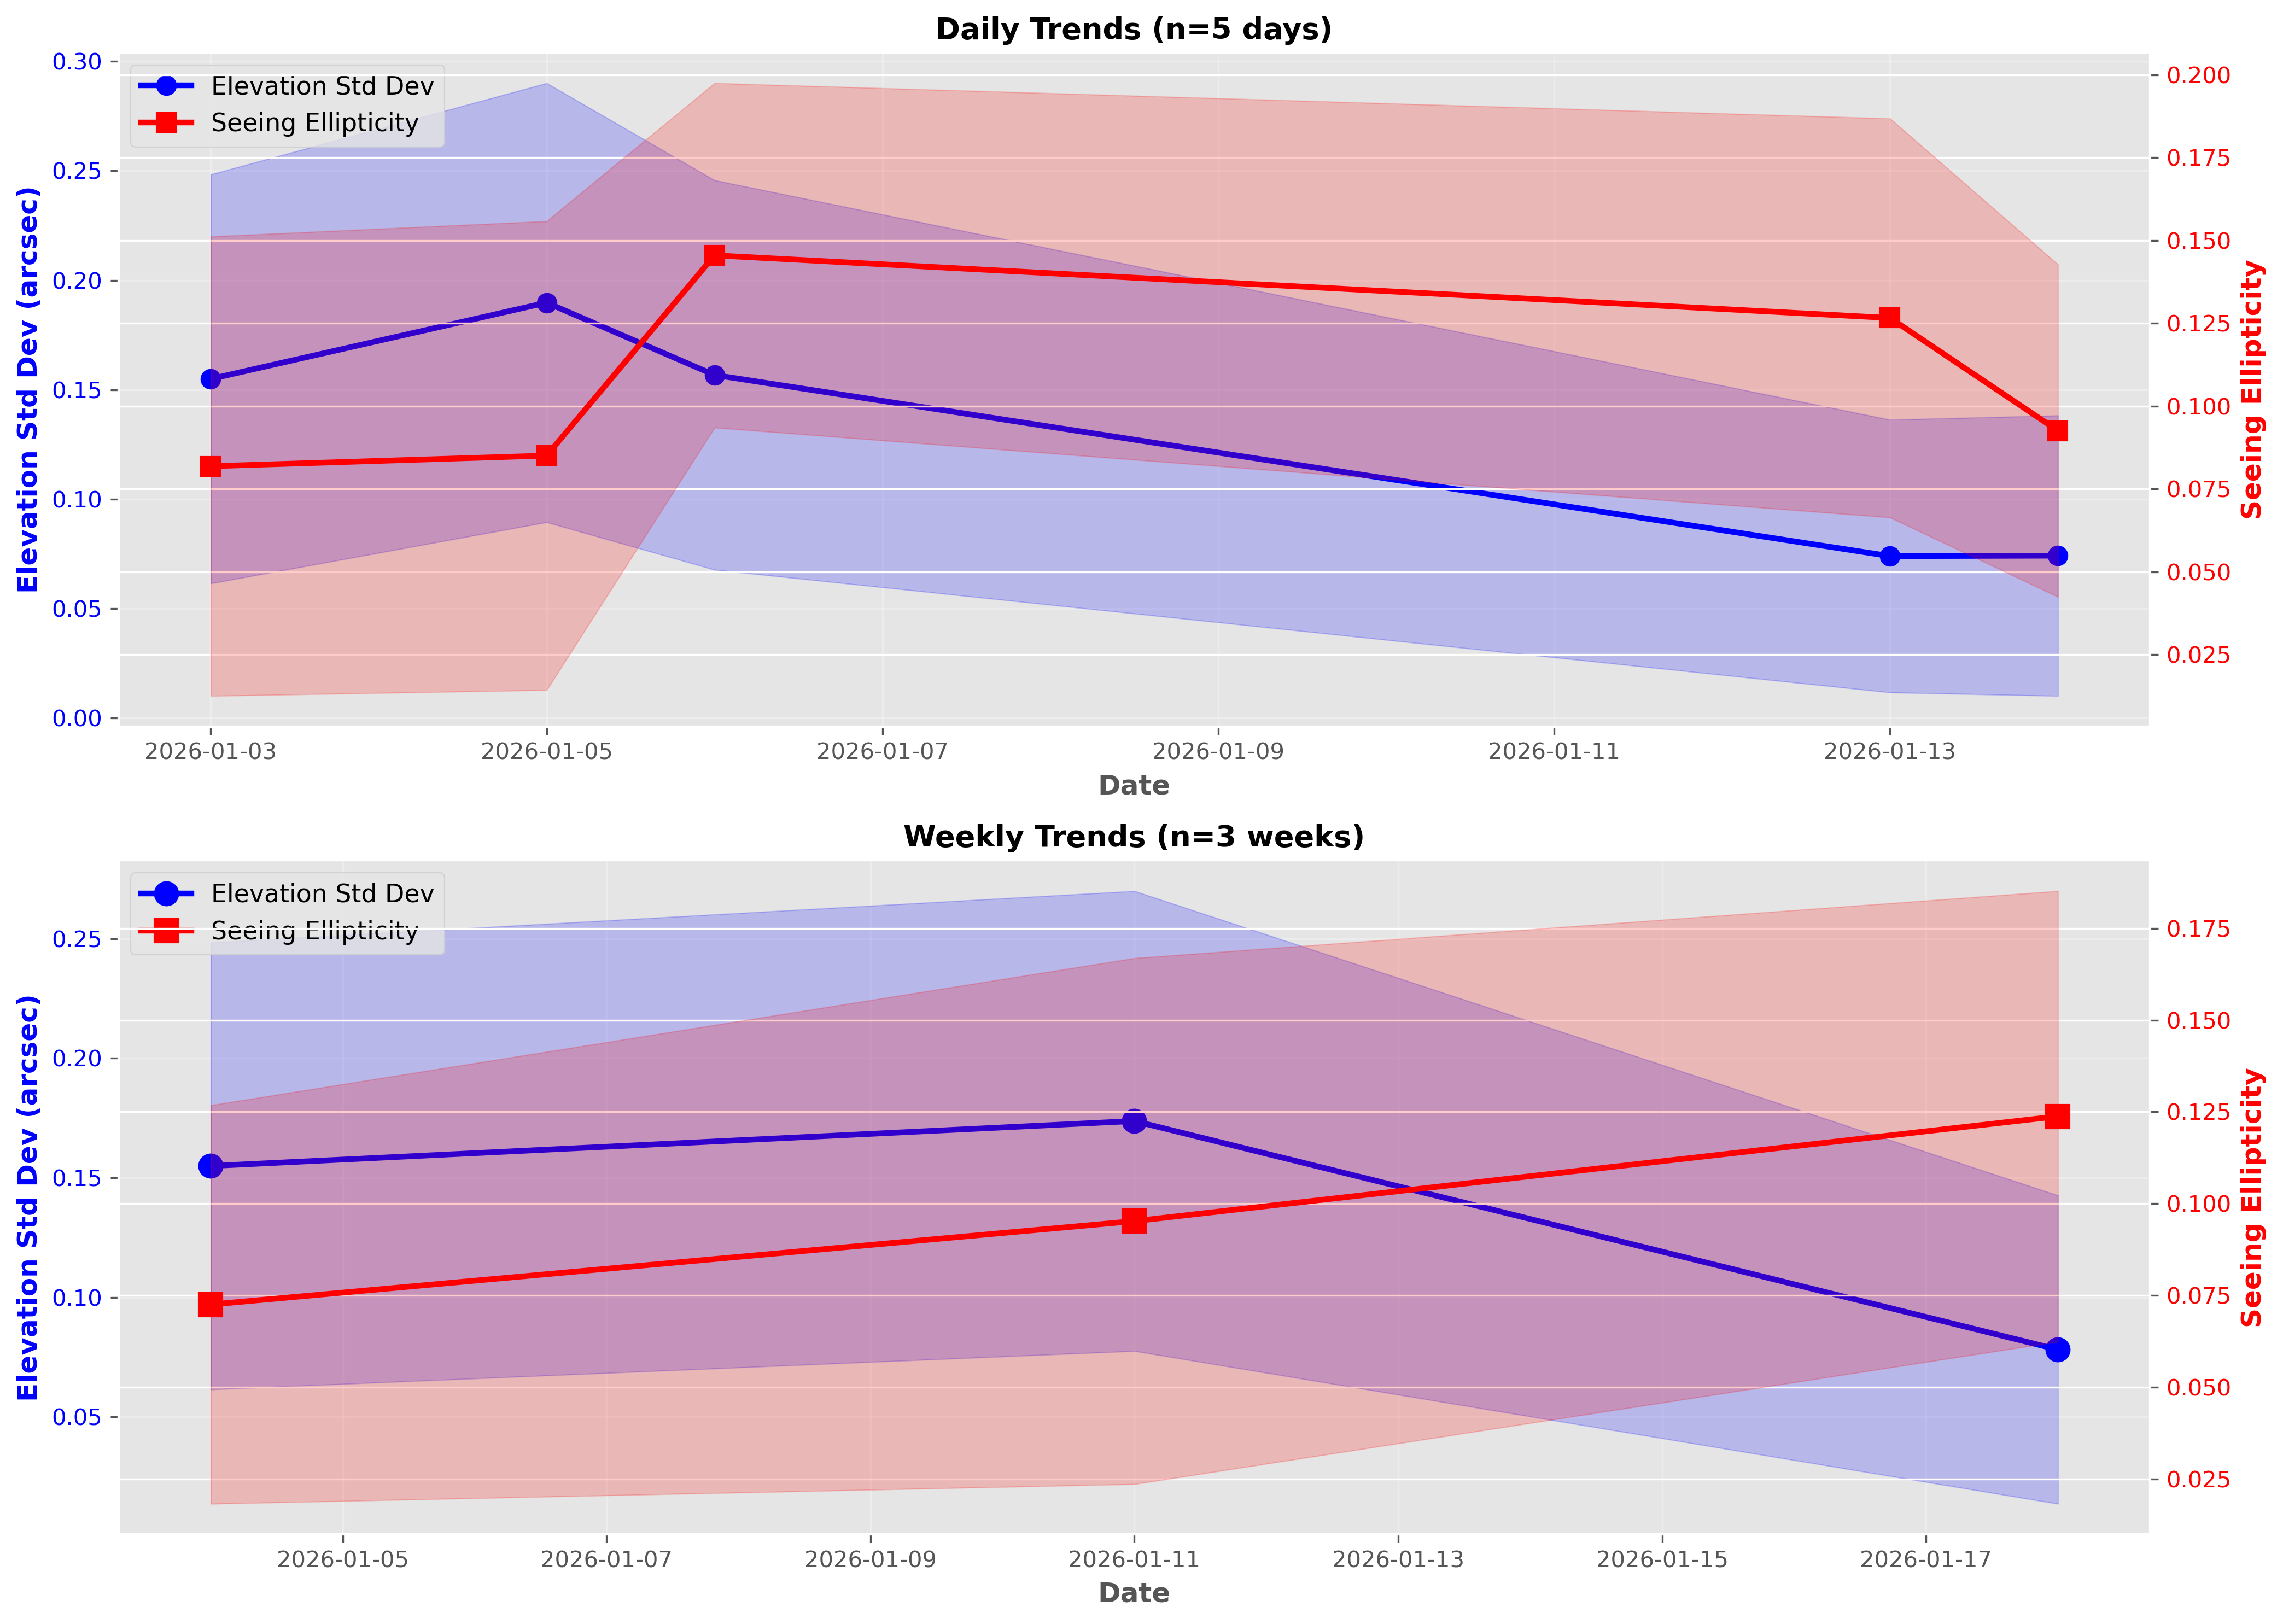

In [33]:
# Display time series plot
import os
from IPython.display import Image, display
if os.path.exists('timeseries_alt_vs_ellipticity.png'):
    display(Image('timeseries_alt_vs_ellipticity.png'))
else:
    print("Time series plot not found. Run Section 7 first.")

## Section 8a: Hexbin Density Visualization
**2D Histogram (hexagonal bins) showing density distribution**

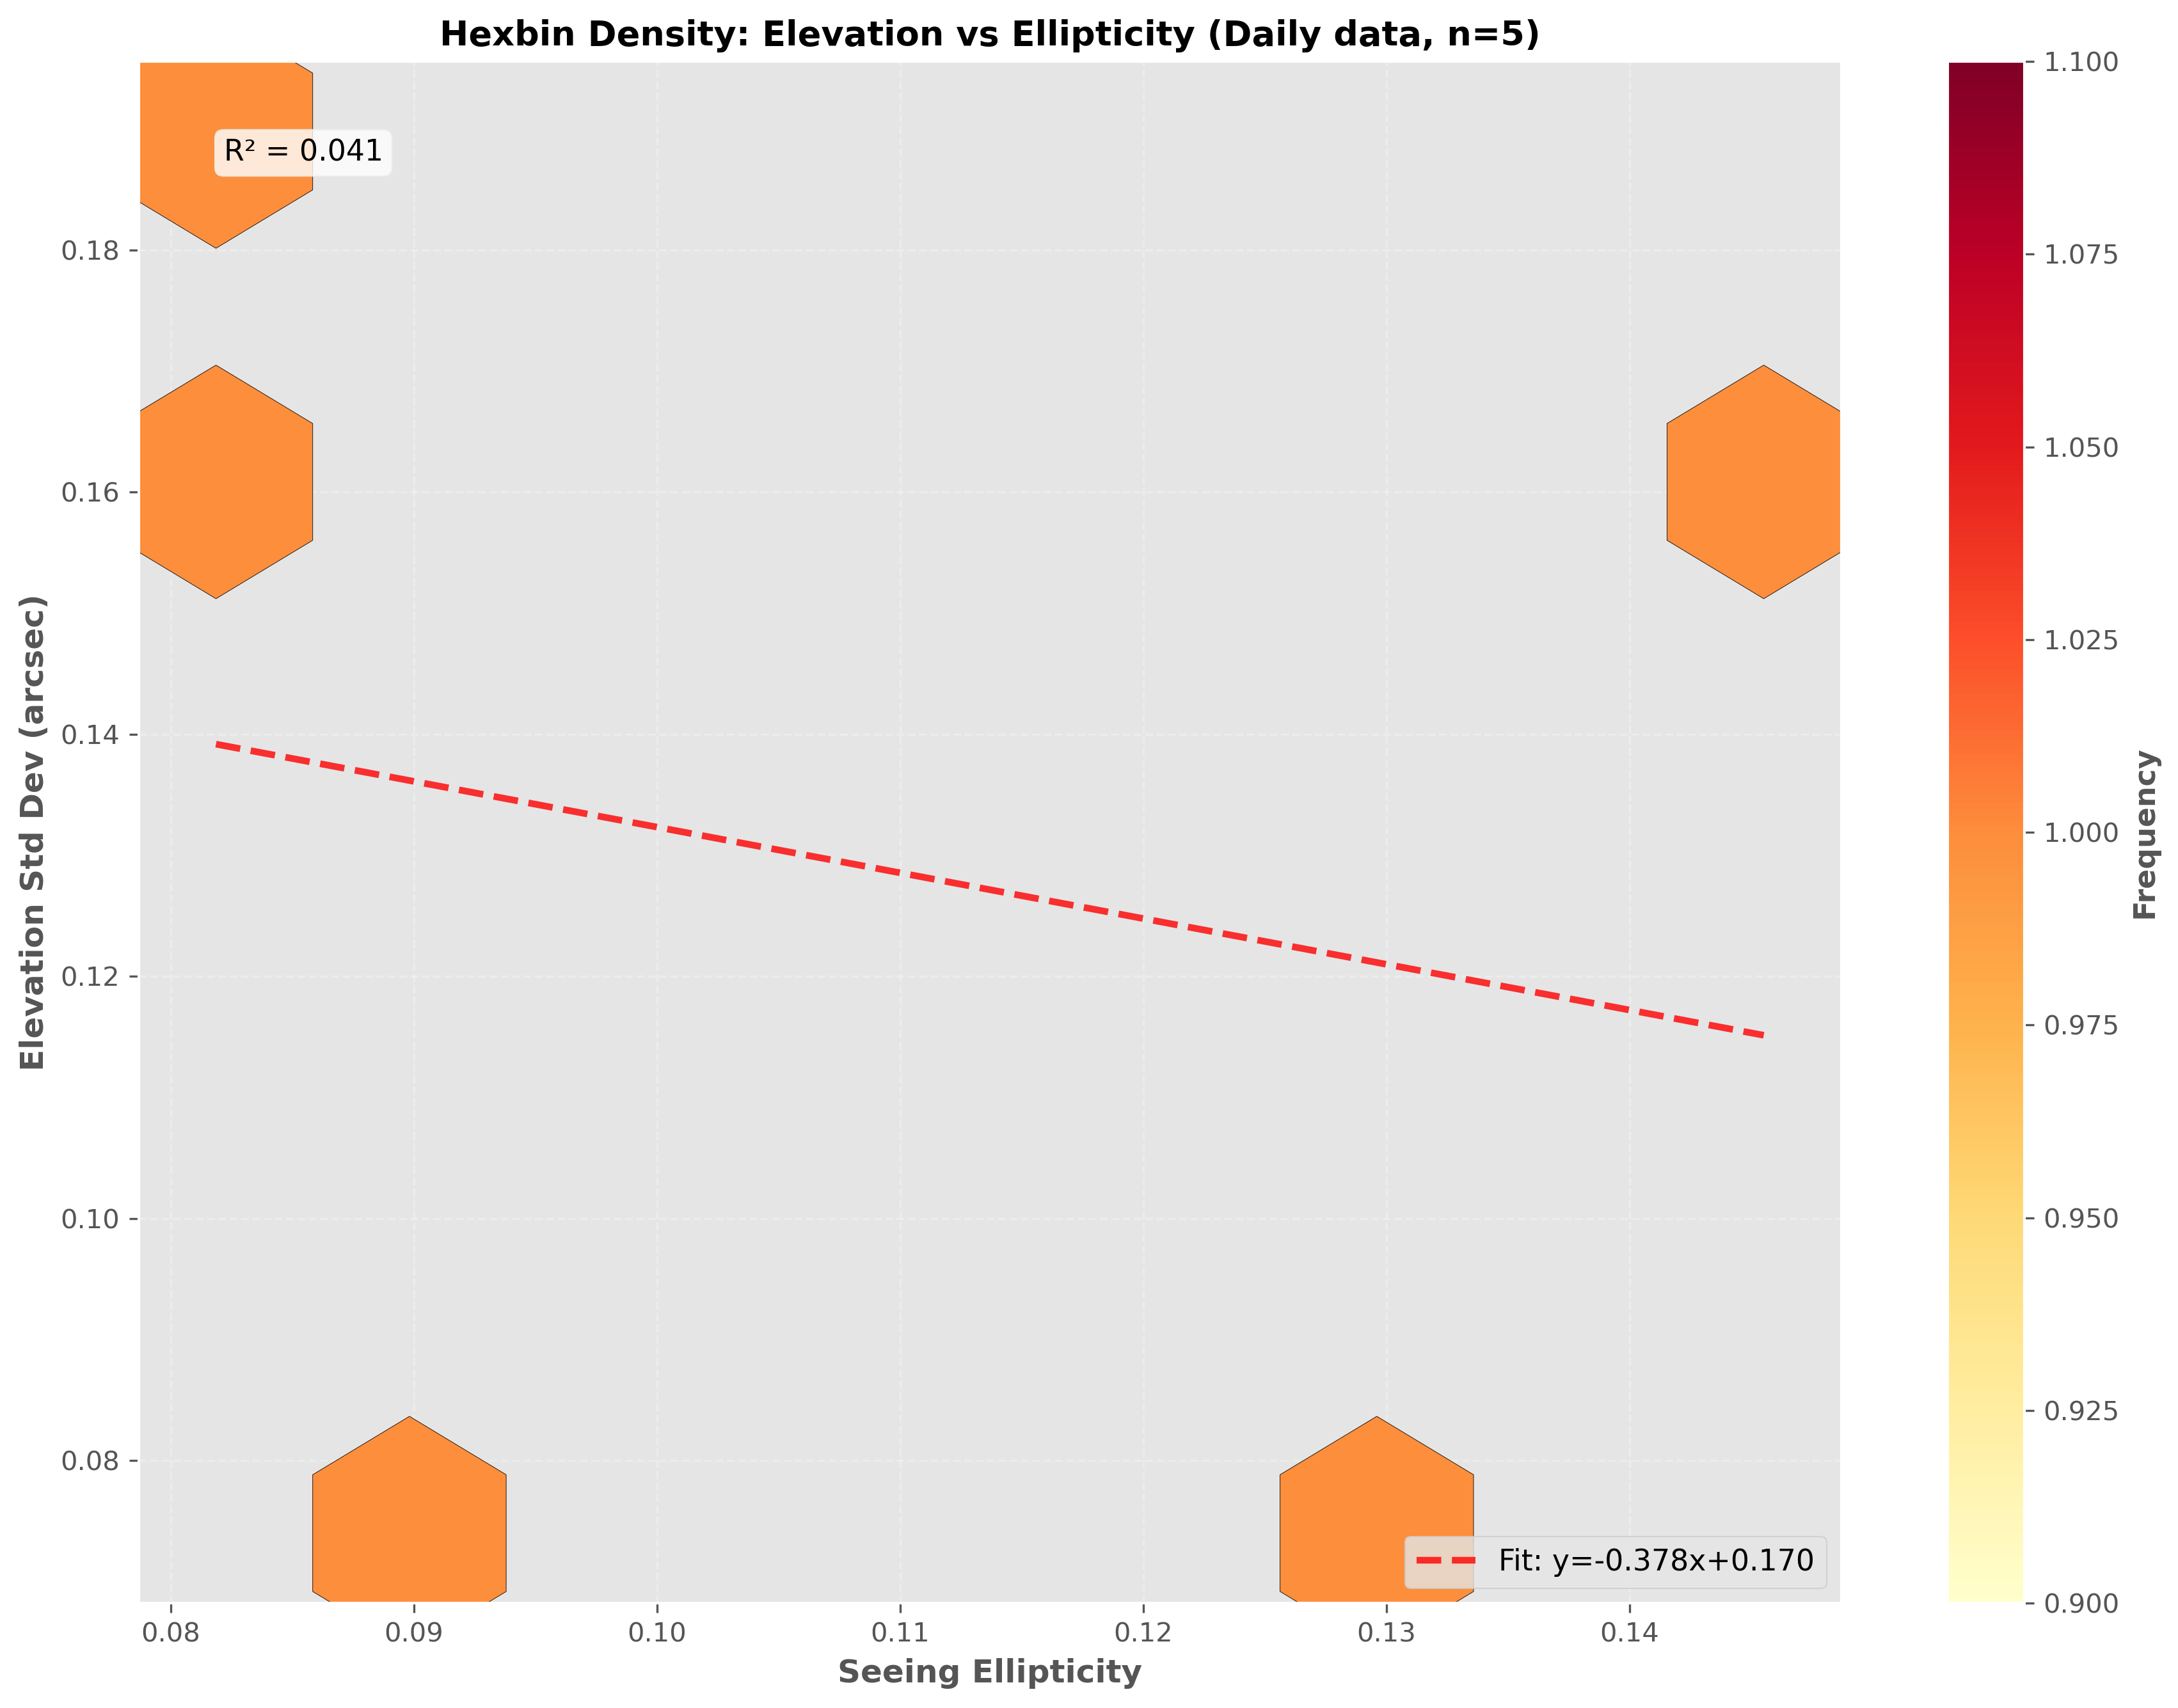

In [35]:
# Display hexbin plot
import os
from IPython.display import Image, display
if os.path.exists('hexbin_alt_vs_ellipticity.png'):
    display(Image('hexbin_alt_vs_ellipticity.png'))
else:
    print("Hexbin plot not found. Run Section 8 first.")

## Section 9a: 2D KDE Density Visualization
**Kernel Density Estimation with contour lines and linear regression**

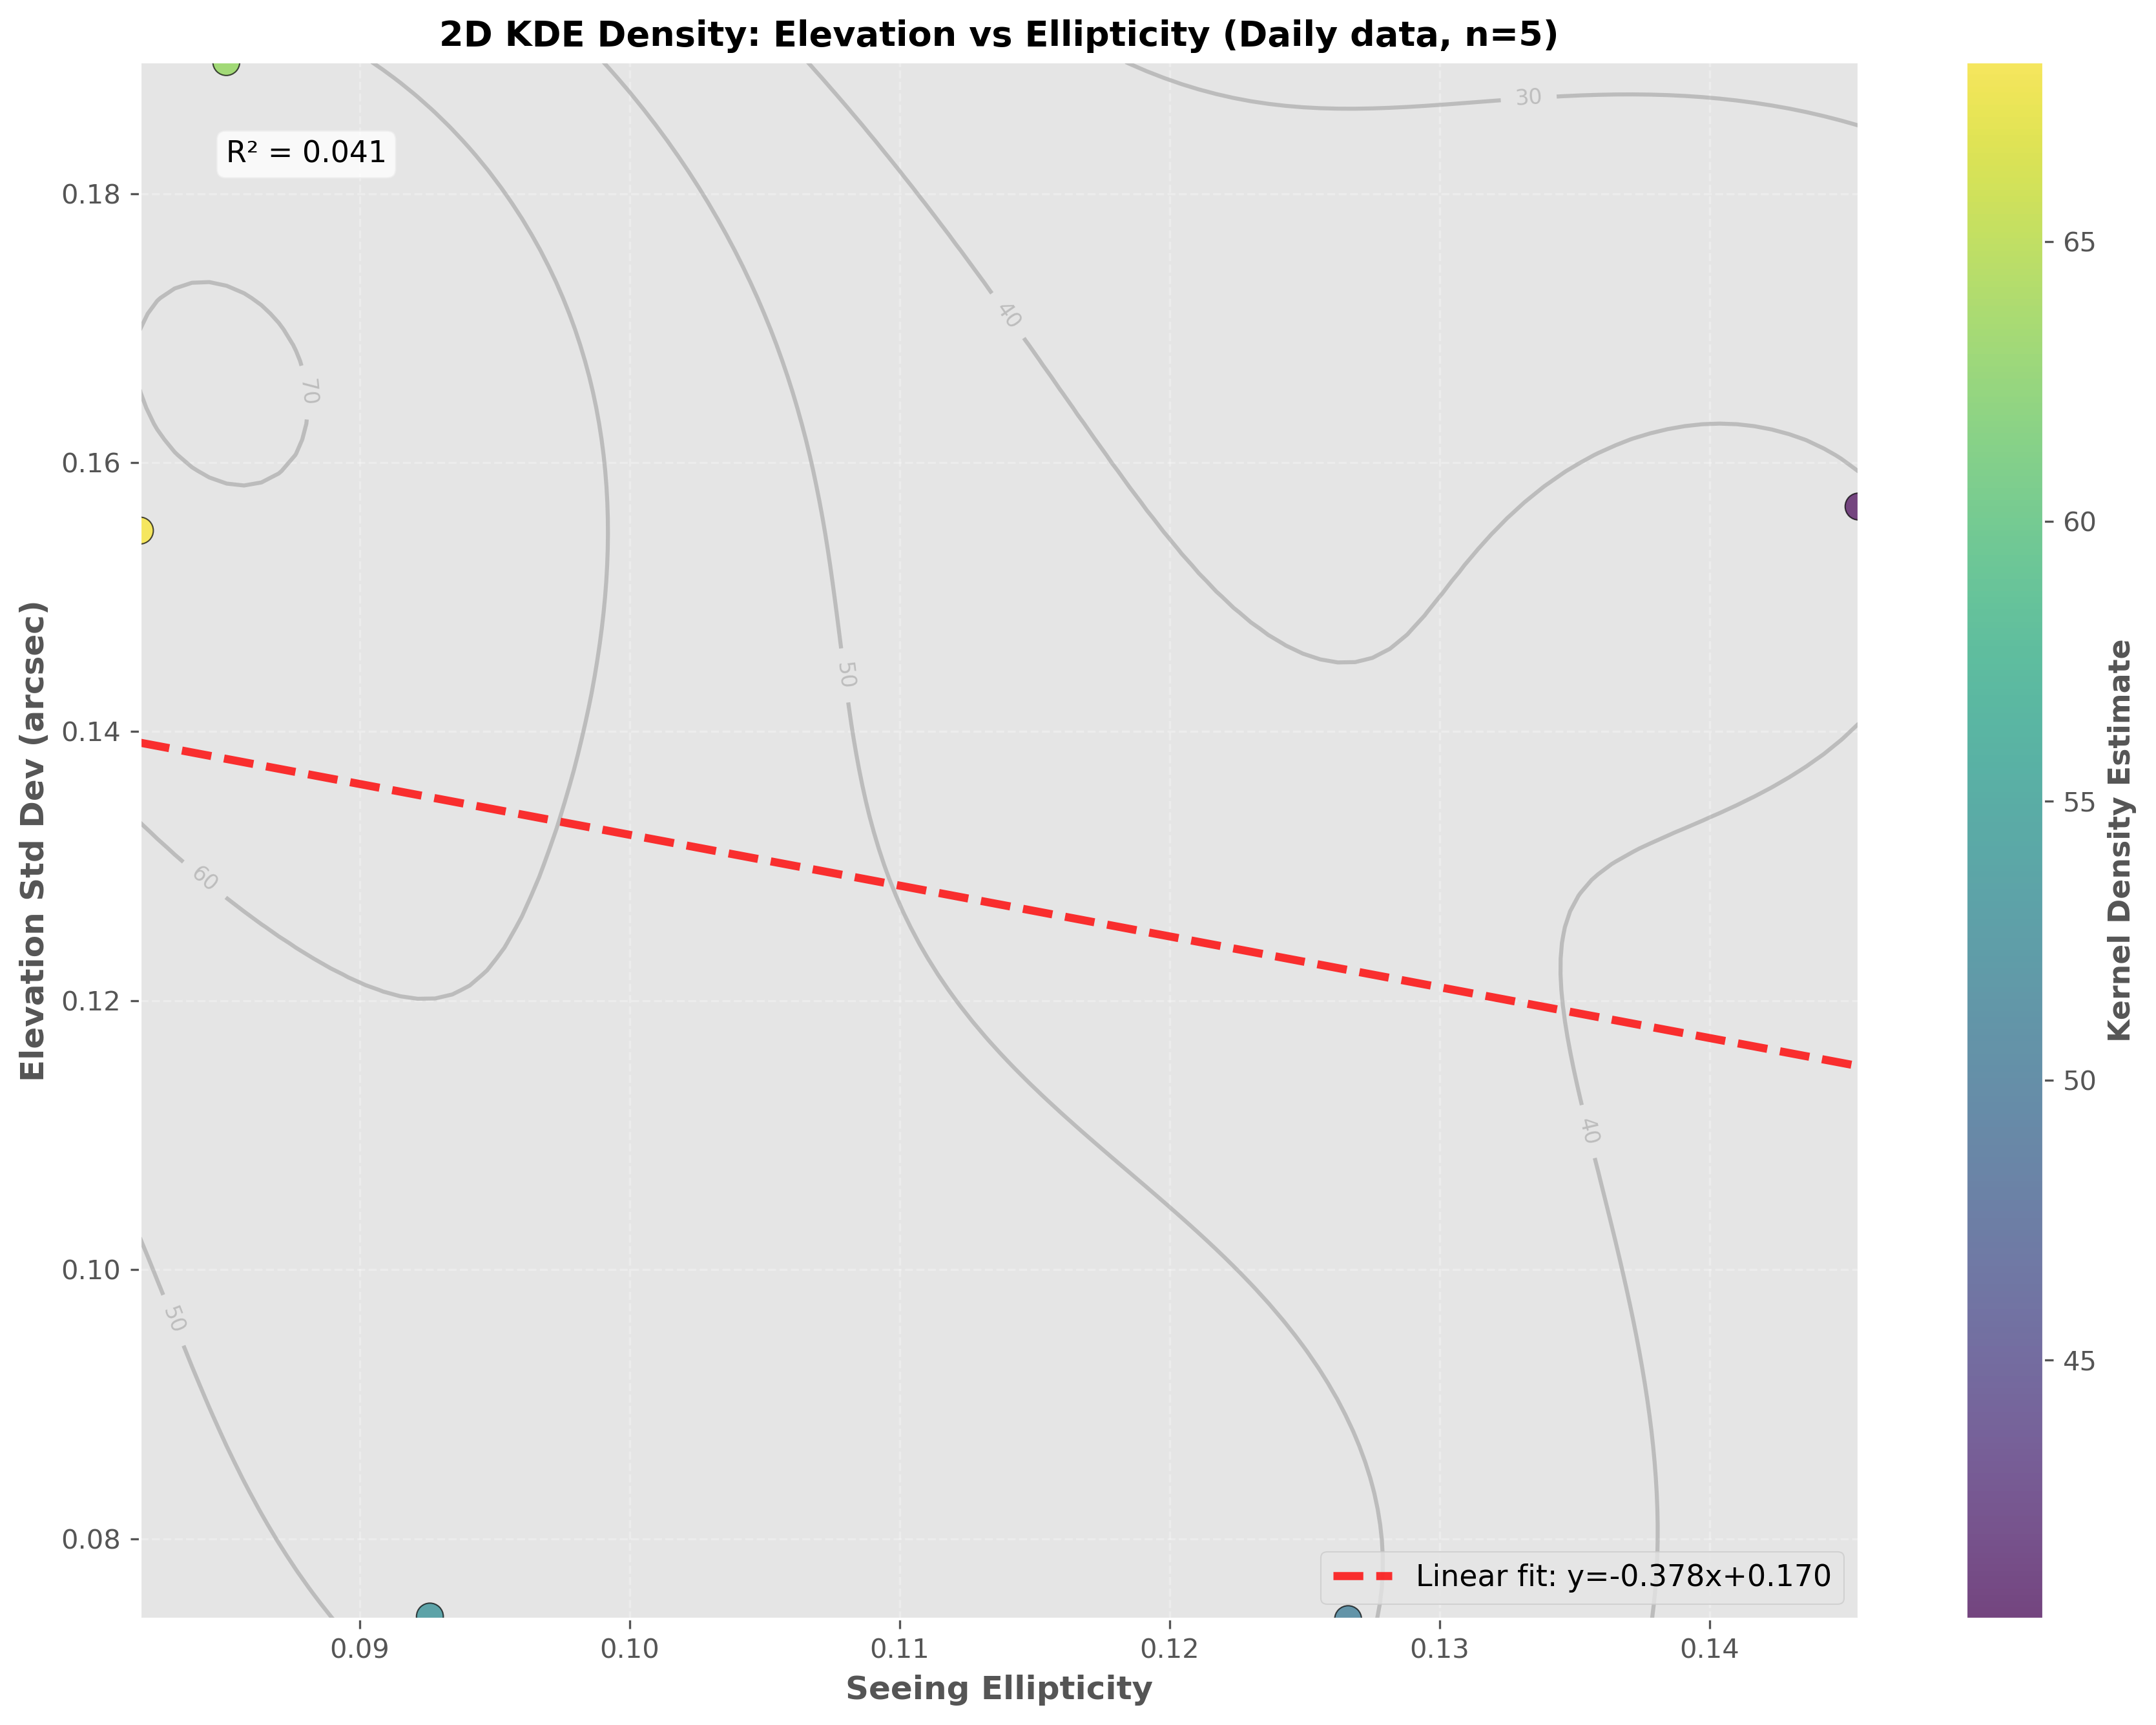

In [37]:
# Display KDE plot
import os
from IPython.display import Image, display
if os.path.exists('kde_alt_vs_ellipticity.png'):
    display(Image('kde_alt_vs_ellipticity.png'))
else:
    print("KDE plot not found. Run Section 9 first.")

In [ ]:
# Section 6: Create Scatter Plot with Trend Analysis
# Generate scatter plot of elevation standard deviation vs seeing with regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create scatter plots for daily and weekly data
resample_sets = [('Daily', df_daily), ('Weekly', df_weekly)]

for idx, (label, df) in enumerate(resample_sets):
    if df is not None and len(df) > 0:
        ax = axes[idx]
        
        # Extract data using correct column names
        x = df['ellip_mean'].values
        y = df['alt_std_mean'].values
        
        # Remove NaN values
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 2:
            # Calculate correlation
            correlation = np.corrcoef(x, y)[0, 1]
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = slope * line_x + intercept
            
            # Scatter plot with error bars
            ax.errorbar(x, y, 
                       xerr=df['ellip_std'].values[mask],
                       yerr=df['alt_std_std'].values[mask],
                       fmt='o', alpha=0.6, markersize=8, capsize=5, 
                       elinewidth=1, capthick=1, label='Data with 1σ')
            ax.plot(line_x, line_y, 'r--', linewidth=2, label=f'Linear fit (R²={r_value**2:.3f})')
            
            # Labels and title
            ax.set_xlabel('Seeing Ellipticity', fontsize=11, fontweight='bold')
            ax.set_ylabel('Elevation Axis Std Dev (arcsec)', fontsize=11, fontweight='bold')
            ax.set_title(f'{label} Data (n={len(x)})\nr={correlation:.3f}, p={p_value:.2e}', 
                        fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=10)
            
            # Print statistics
            print(f"\n{label} Scatter Statistics:")
            print(f"  Points: {len(x)}")
            print(f"  Correlation coefficient: {correlation:.4f}")
            print(f"  Slope: {slope:.4f} arcsec/arcsec")
            print(f"  Intercept: {intercept:.4f} arcsec")
            print(f"  R-squared: {r_value**2:.4f}")
            print(f"  P-value: {p_value:.2e}")
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})', 
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data available', 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('scatter_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.close()

print("\n✓ Scatter plot saved as 'scatter_alt_vs_seeing.png'")


Daily Scatter Statistics:
  Points: 5
  Correlation coefficient: -0.0412
  Slope: -0.0140 arcsec/arcsec
  Intercept: 0.1458 arcsec
  R-squared: 0.0017
  P-value: 9.48e-01

Weekly Scatter Statistics:
  Points: 3
  Correlation coefficient: 0.0334
  Slope: 0.0133 arcsec/arcsec
  Intercept: 0.1209 arcsec
  R-squared: 0.0011
  P-value: 9.79e-01

✓ Scatter plot saved as 'scatter_alt_vs_seeing.png'


In [19]:
# Section 6a: Diagnostic - Check Available Data
# Examine data structures and column names

print("="*70)
print("DATA AVAILABILITY DIAGNOSTIC")
print("="*70)

data_inventory = {
    'df_telescope_alterr': (df_telescope_alterr, "Raw elevation data"),
    'df_alterr_2min_clean': (df_alterr_2min_clean, "2-min resampled elevation"),
    'df_alt_std': (df_alt_std, "Elevation std extracted"),
    'df_seeing': (df_seeing, "WFS seeing measurements"),
    'df_ellipticity': (df_ellipticity, "WFS ellipticity"),
    'df_daily': (df_daily, "Daily aggregation"),
    'df_weekly': (df_weekly, "Weekly aggregation"),
    'df_monthly': (df_monthly, "Monthly aggregation"),
}

for var_name, (df, description) in data_inventory.items():
    if df is not None and len(df) > 0:
        print(f"\n✓ {var_name}: {len(df)} rows - {description}")
        print(f"  Columns: {list(df.columns)}")
        print(f"  Date range: {df.index.min()} to {df.index.max()}")
    else:
        print(f"\n✗ {var_name}: No data - {description}")

print("\n" + "="*70)


DATA AVAILABILITY DIAGNOSTIC

✓ df_telescope_alterr: 4272802 rows - Raw elevation data
  Columns: ['telescope_alterr_arcsec']
  Date range: 2026-01-03 02:28:11.692329 to 2026-01-15 06:57:01.783859

✓ df_alterr_2min_clean: 710 rows - 2-min resampled elevation
  Columns: ['std', 'mean', 'min', 'max', 'count']
  Date range: 2026-01-03 02:28:00 to 2026-01-15 06:56:00

✓ df_alt_std: 710 rows - Elevation std extracted
  Columns: ['altitude_std', 'altitude_mean', 'altitude_min', 'altitude_max', 'sample_count']
  Date range: 2026-01-03 02:28:00 to 2026-01-15 06:56:00

✓ df_seeing: 3651 rows - WFS seeing measurements
  Columns: ['timestamp', 'seeing_arcsec']
  Date range: 2026-01-02 19:41:03 to 2026-01-14 23:59:39

✓ df_ellipticity: 3651 rows - WFS ellipticity
  Columns: ['timestamp', 'ellipticity']
  Date range: 2026-01-02 19:41:03 to 2026-01-14 23:59:39

✓ df_daily: 5 rows - Daily aggregation
  Columns: ['alt_std_mean', 'alt_std_std', 'alt_std_min', 'alt_std_max', 'alt_count', 'seeing_mean', 

In [21]:
# Section 7: Generate Time Series Visualization (CORRECTED)
# Create dual-axis time series plots showing trends over time with correct column names

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily time series with dual axes
if df_daily is not None and len(df_daily) > 0:
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Plot elevation std on left axis
    line1 = ax1.plot(df_daily.index, df_daily['alt_std_mean'], 'b-o', linewidth=2.5, markersize=8, label='Elevation Std Dev')
    ax1.fill_between(df_daily.index, 
                      df_daily['alt_std_mean'] - df_daily['alt_std_std'],
                      df_daily['alt_std_mean'] + df_daily['alt_std_std'],
                      alpha=0.2, color='blue')
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold', color='b')
    ax1.tick_params(axis='y', labelcolor='b', labelsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot seeing on right axis
    if 'seeing_mean' in df_daily.columns:
        line2 = ax1_twin.plot(df_daily.index, df_daily['seeing_mean'], 'r-s', linewidth=2.5, markersize=8, label='Atmospheric Seeing')
        ax1_twin.fill_between(df_daily.index,
                             df_daily['seeing_mean'] - df_daily['seeing_std'],
                             df_daily['seeing_mean'] + df_daily['seeing_std'],
                             alpha=0.2, color='red')
        ax1_twin.set_ylabel('Atmospheric Seeing (arcsec)', fontsize=12, fontweight='bold', color='r')
        ax1_twin.tick_params(axis='y', labelcolor='r', labelsize=10)
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1_twin.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    
    ax1.set_title(f'Daily Trends (n={len(df_daily)} days)', fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No daily data available', ha='center', va='center', transform=axes[0].transAxes, fontsize=11)

# Weekly time series
if df_weekly is not None and len(df_weekly) > 0:
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    line1 = ax2.plot(df_weekly.index, df_weekly['alt_std_mean'], 'b-o', linewidth=2.5, markersize=10, label='Elevation Std Dev')
    ax2.fill_between(df_weekly.index,
                     df_weekly['alt_std_mean'] - df_weekly['alt_std_std'],
                     df_weekly['alt_std_mean'] + df_weekly['alt_std_std'],
                     alpha=0.2, color='blue')
    ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Elevation Std Dev (arcsec)', fontsize=12, fontweight='bold', color='b')
    ax2.tick_params(axis='y', labelcolor='b', labelsize=10)
    ax2.grid(True, alpha=0.3)
    
    if 'seeing_mean' in df_weekly.columns:
        line2 = ax2_twin.plot(df_weekly.index, df_weekly['seeing_mean'], 'r-s', linewidth=2.5, markersize=10, label='Atmospheric Seeing')
        ax2_twin.fill_between(df_weekly.index,
                             df_weekly['seeing_mean'] - df_weekly['seeing_std'],
                             df_weekly['seeing_mean'] + df_weekly['seeing_std'],
                             alpha=0.2, color='red')
        ax2_twin.set_ylabel('Atmospheric Seeing (arcsec)', fontsize=12, fontweight='bold', color='r')
        ax2_twin.tick_params(axis='y', labelcolor='r', labelsize=10)
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    
    ax2.set_title(f'Weekly Trends (n={len(df_weekly)} weeks)', fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No weekly data available', ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('timeseries_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Corrected time series plot saved as 'timeseries_alt_vs_seeing.png'")


✓ Corrected time series plot saved as 'timeseries_alt_vs_seeing.png'



CORRECTED TIME SERIES: Daily/Weekly Trends


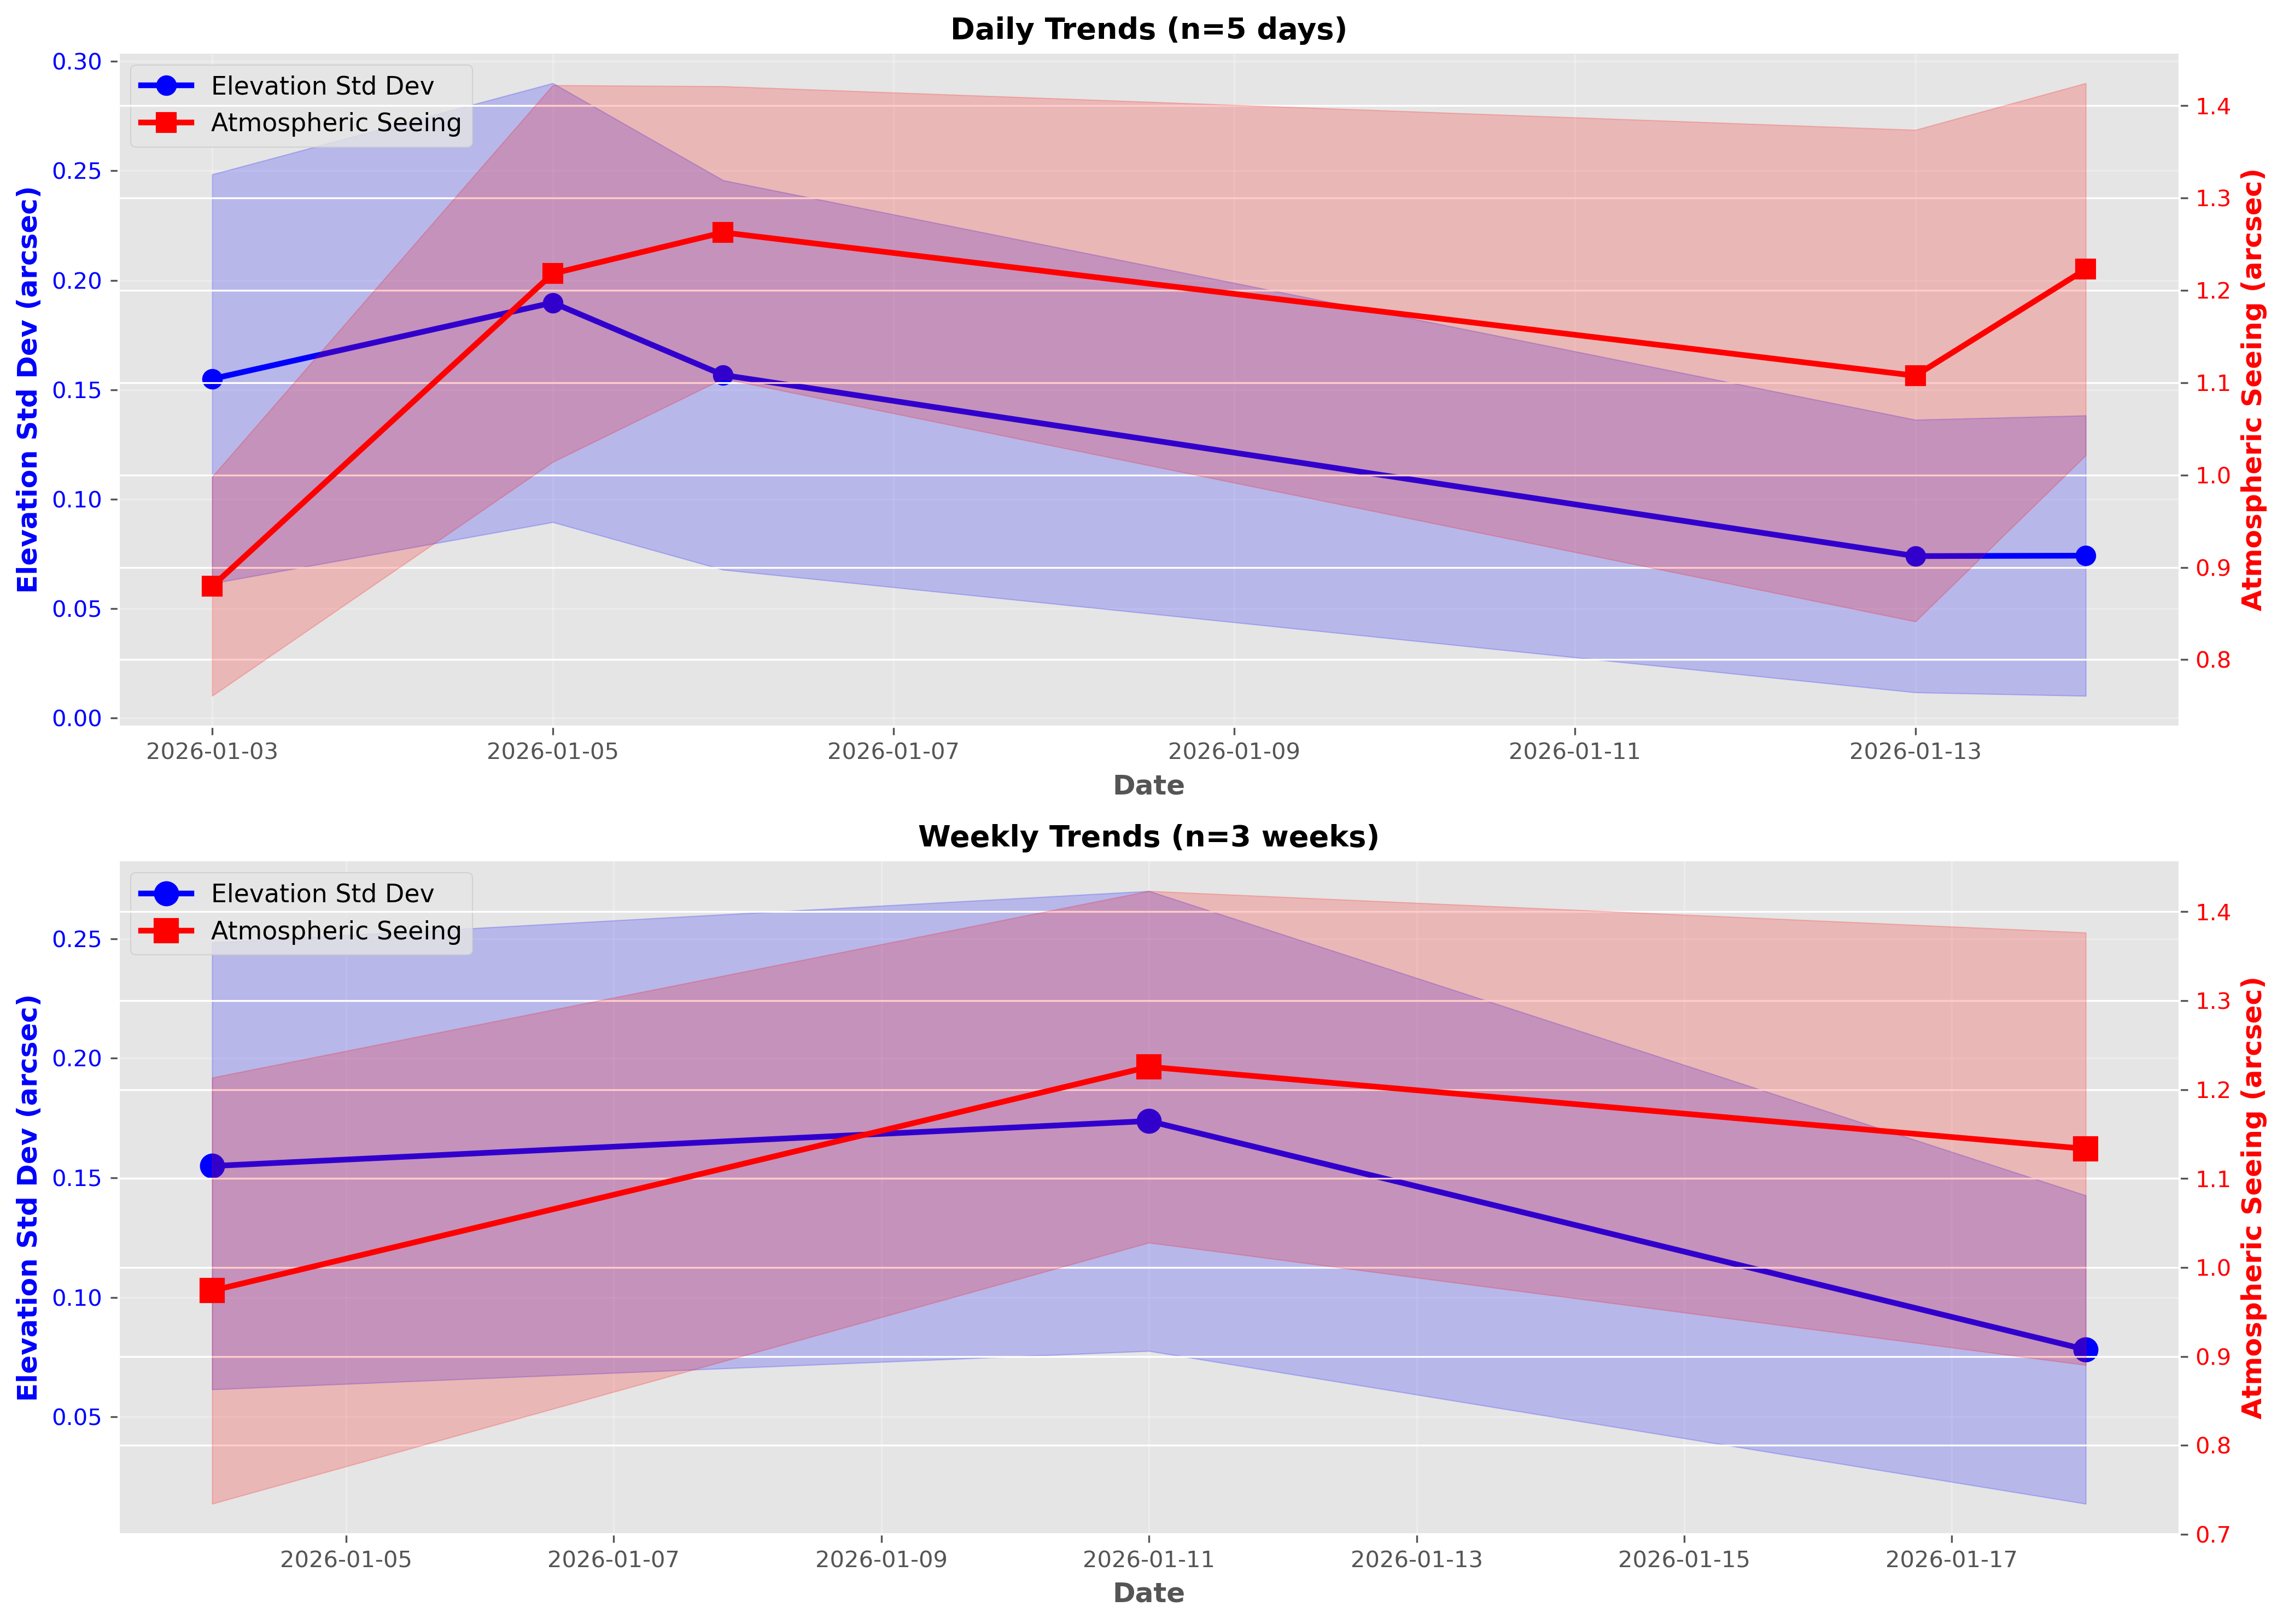

In [25]:
# Display the corrected time series plot
from IPython.display import Image, display

print("\n" + "="*60)
print("CORRECTED TIME SERIES: Daily/Weekly Trends")
print("="*60)
display(Image(filename='timeseries_alt_vs_seeing.png'))


In [22]:
# Section 8: Produce Hexbin Density Plot (CORRECTED)
# Hexbin visualization to show density distribution with correct column names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resample_sets = [('Daily', df_daily), ('Weekly', df_weekly)]

for idx, (label, df) in enumerate(resample_sets):
    if df is not None and len(df) > 2:
        ax = axes[idx]
        
        x = df['seeing_mean'].values
        y = df['alt_std_mean'].values
        
        # Remove NaN values
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 2:
            # Create hexbin plot
            hb = ax.hexbin(x, y, gridsize=4, cmap='YlOrRd', mincnt=1, edgecolors='black', linewidths=0.5)
            
            # Add regression line
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = slope * line_x + intercept
            ax.plot(line_x, line_y, 'b--', linewidth=2.5, label=f'Linear fit (R²={r_value**2:.3f})')
            
            ax.set_xlabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Elevation Std Dev (arcsec)', fontsize=11, fontweight='bold')
            ax.set_title(f'{label} Data Density (n={len(x)})', fontsize=12, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Colorbar
            cb = plt.colorbar(hb, ax=ax)
            cb.set_label('Frequency', fontsize=10)
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})',
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data available',
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('hexbin_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.close()

print("\n✓ Corrected hexbin density plot saved as 'hexbin_alt_vs_seeing.png'")



✓ Corrected hexbin density plot saved as 'hexbin_alt_vs_seeing.png'



HEXBIN DENSITY: Daily/Weekly Data Distribution


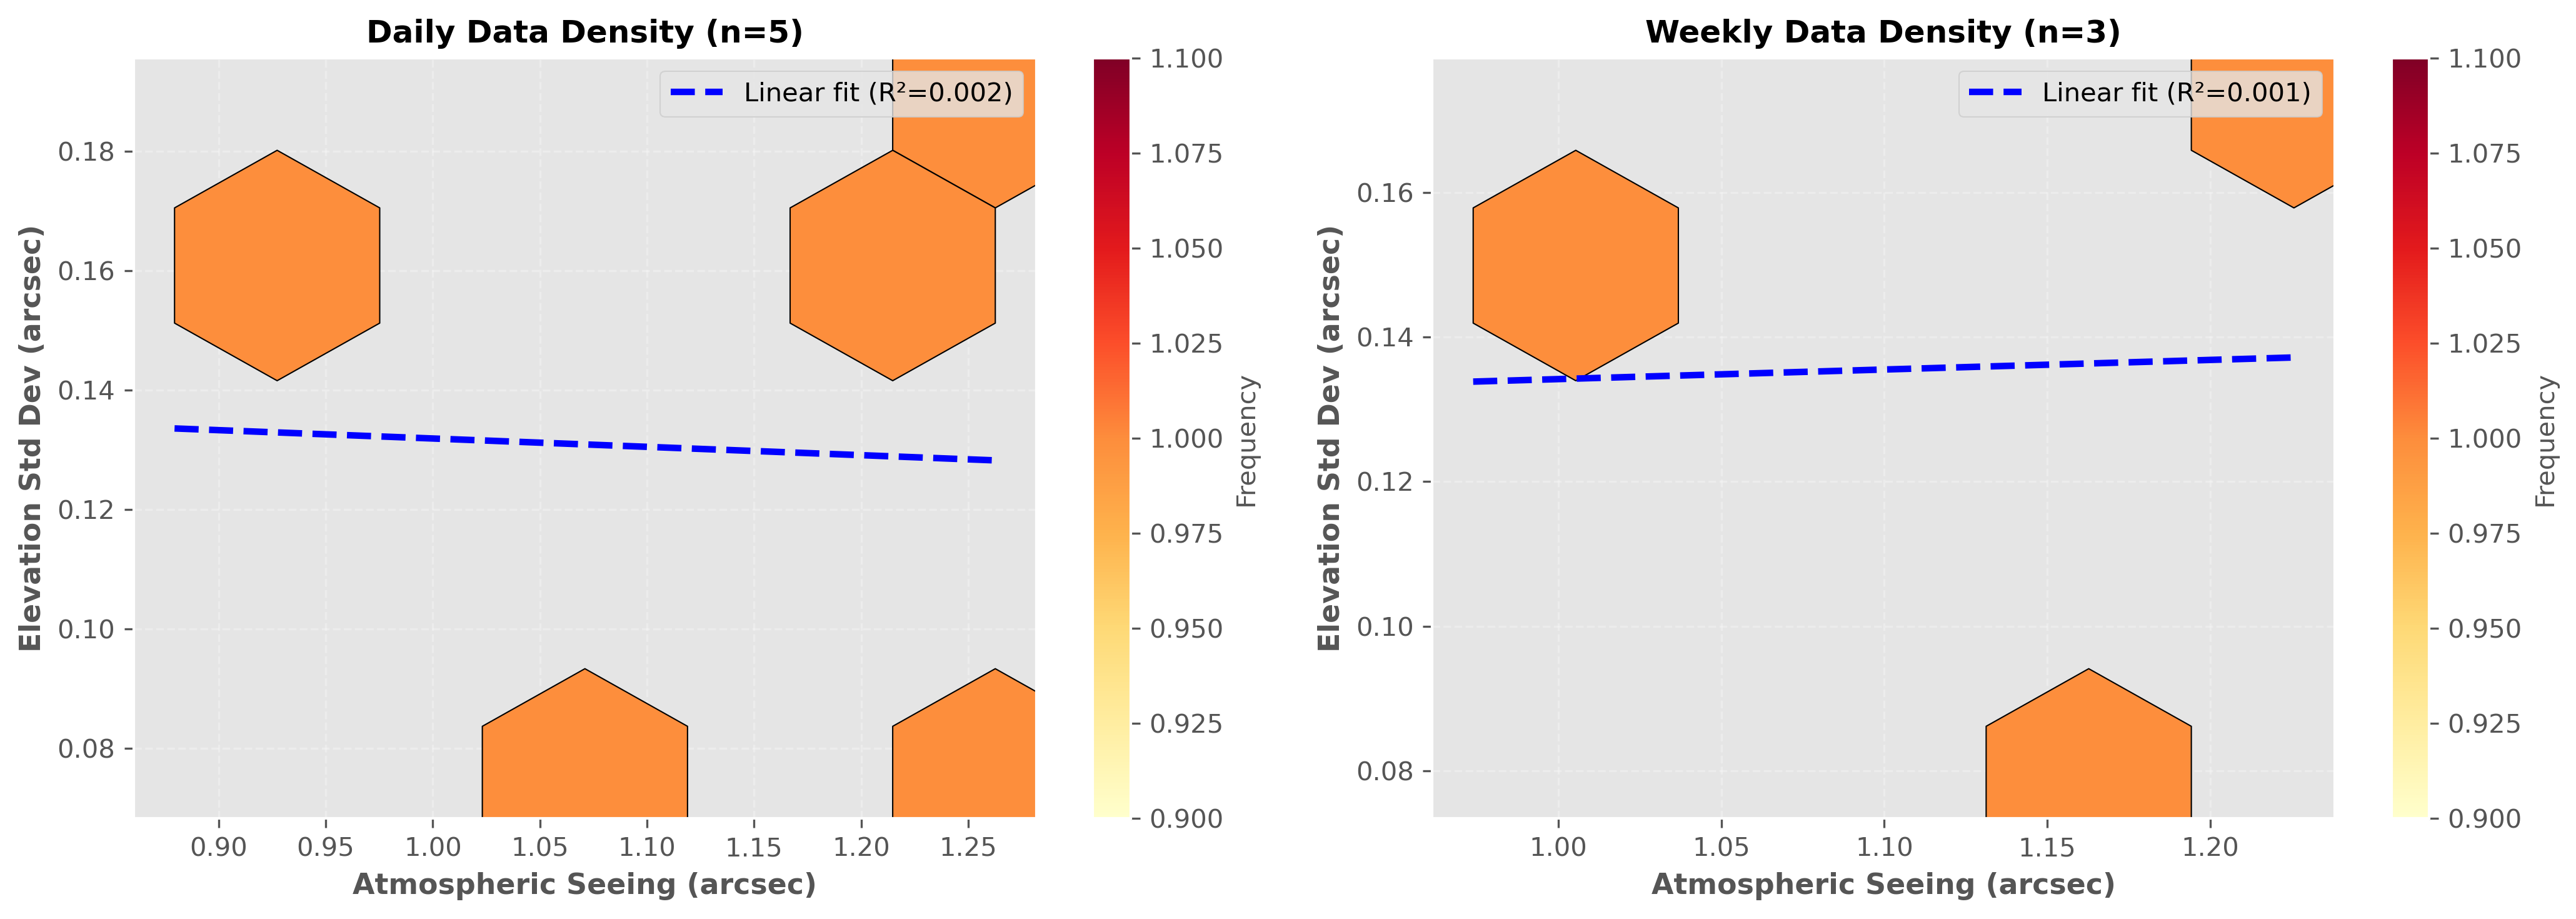

In [26]:
# Display the hexbin density plot
print("\n" + "="*60)
print("HEXBIN DENSITY: Daily/Weekly Data Distribution")
print("="*60)
display(Image(filename='hexbin_alt_vs_seeing.png'))


In [23]:
# Section 9: 2D Kernel Density Estimation Plot (CORRECTED)
# Creates smooth density contours for publication-quality figures

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resample_sets = [('Daily', df_daily), ('Weekly', df_weekly)]

for idx, (label, df) in enumerate(resample_sets):
    if df is not None and len(df) > 2:
        ax = axes[idx]
        
        x = df['seeing_mean'].values
        y = df['alt_std_mean'].values
        
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 3:
            try:
                # Compute 2D kernel density
                xy = np.vstack([x, y])
                z = gaussian_kde(xy)(xy)
                
                # Sort by density so densest points are plotted last
                idx_sort = np.argsort(z)
                x_sort, y_sort, z_sort = x[idx_sort], y[idx_sort], z[idx_sort]
                
                # Scatter plot colored by density
                scatter = ax.scatter(x_sort, y_sort, c=z_sort, s=100, cmap='viridis', 
                                   edgecolors='k', linewidth=0.5, alpha=0.8)
                
                # Add regression line
                slope, intercept, r_value, _, _ = linregress(x, y)
                line_x = np.array([x.min(), x.max()])
                line_y = slope * line_x + intercept
                ax.plot(line_x, line_y, 'r--', linewidth=2.5, label=f'Linear fit (R²={r_value**2:.3f})')
                
                ax.set_xlabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold')
                ax.set_ylabel('Elevation Std Dev (arcsec)', fontsize=11, fontweight='bold')
                ax.set_title(f'{label} Data with Kernel Density (n={len(x)})', fontsize=12, fontweight='bold')
                ax.legend(fontsize=10)
                ax.grid(True, alpha=0.3, linestyle='--')
                
                cb = plt.colorbar(scatter, ax=ax)
                cb.set_label('Density', fontsize=10)
            except Exception as e:
                ax.text(0.5, 0.5, f'KDE Error: {str(e)[:30]}',
                       ha='center', va='center', transform=ax.transAxes, fontsize=9)
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})',
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data',
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('kde_density_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Corrected 2D KDE density plot saved as 'kde_density_alt_vs_seeing.png'")


✓ Corrected 2D KDE density plot saved as 'kde_density_alt_vs_seeing.png'



2D KERNEL DENSITY ESTIMATION: Daily/Weekly Data


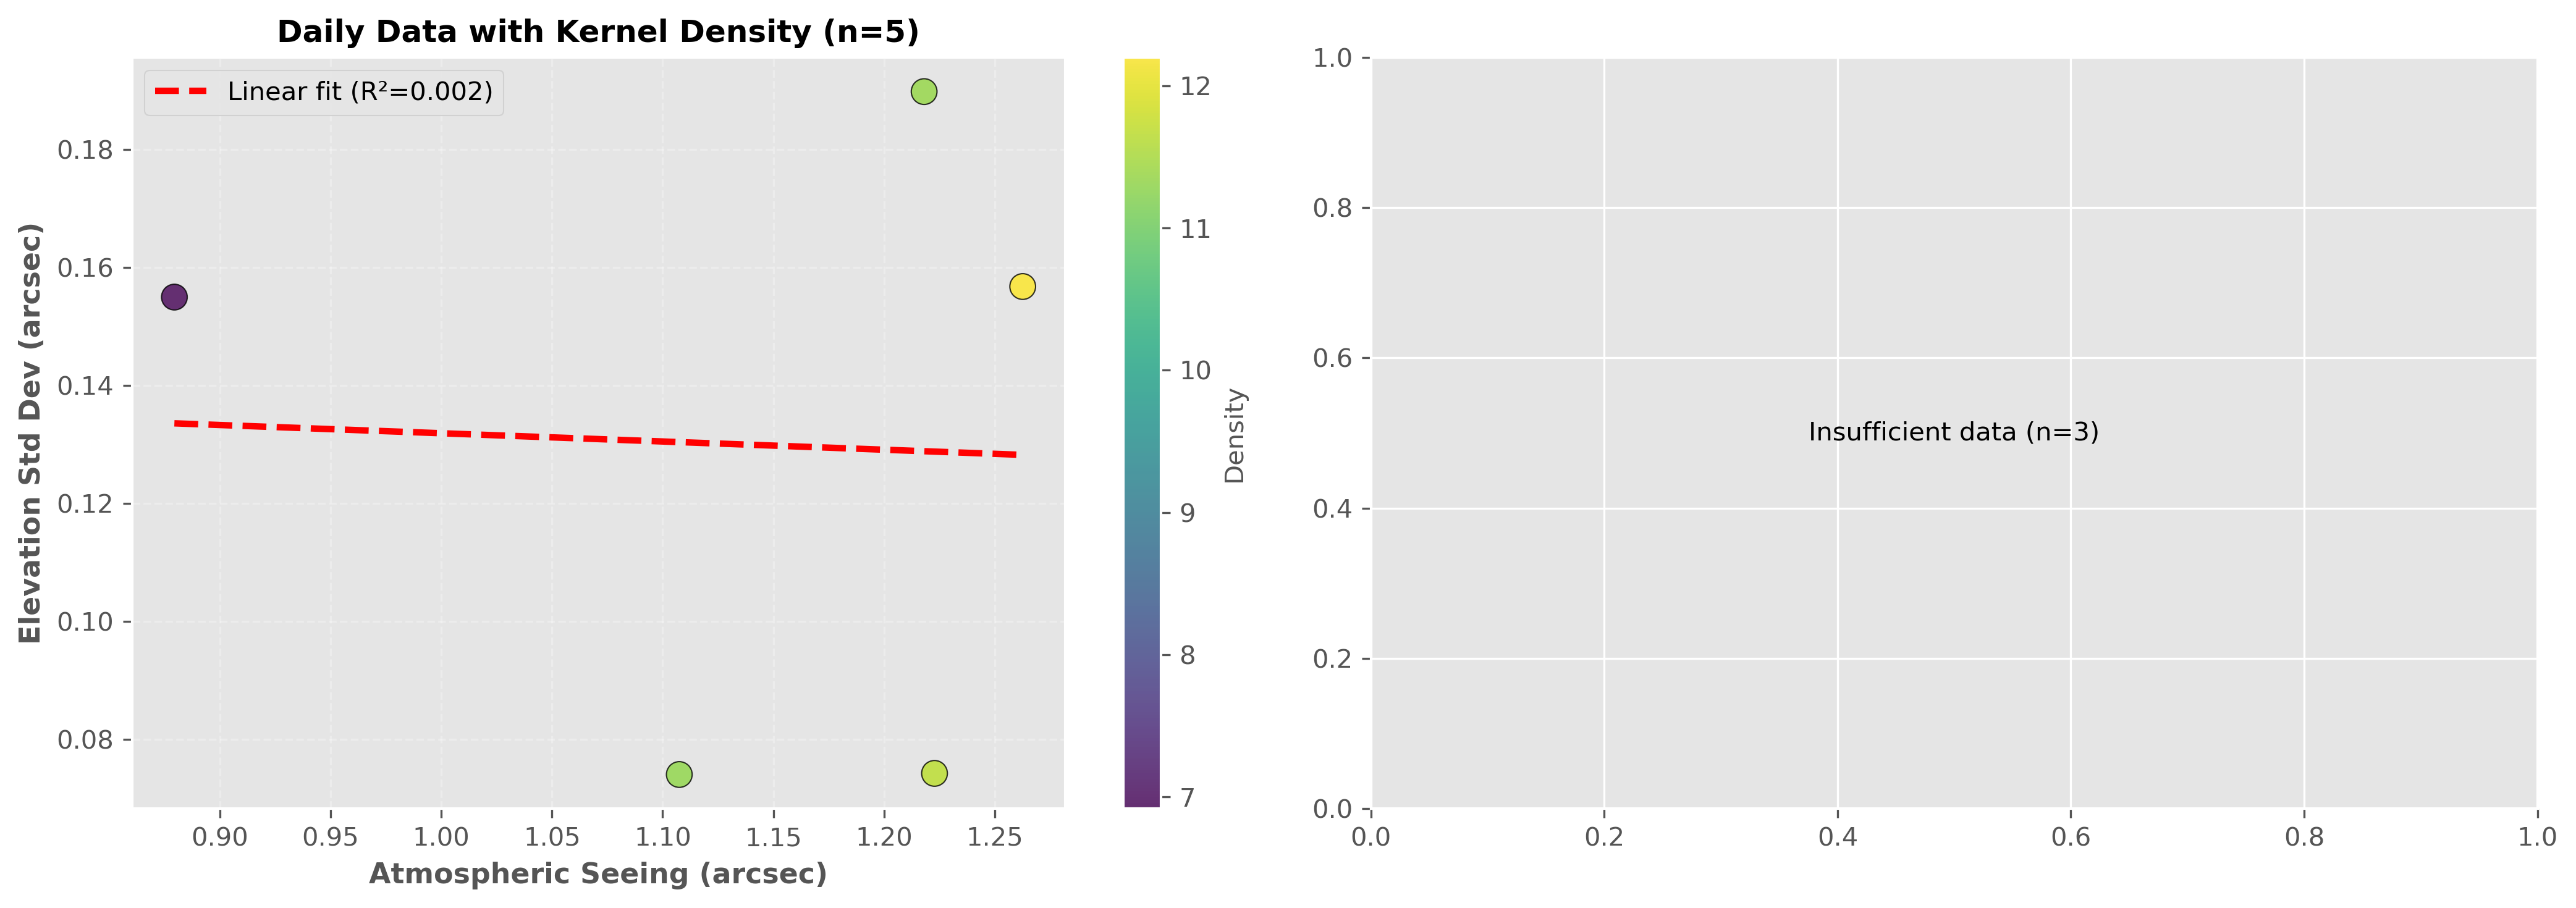

In [27]:
# Display the KDE density plot
print("\n" + "="*60)
print("2D KERNEL DENSITY ESTIMATION: Daily/Weekly Data")
print("="*60)
display(Image(filename='kde_density_alt_vs_seeing.png'))



SCATTER PLOT: Daily/Weekly/Monthly Data with Regression Analysis


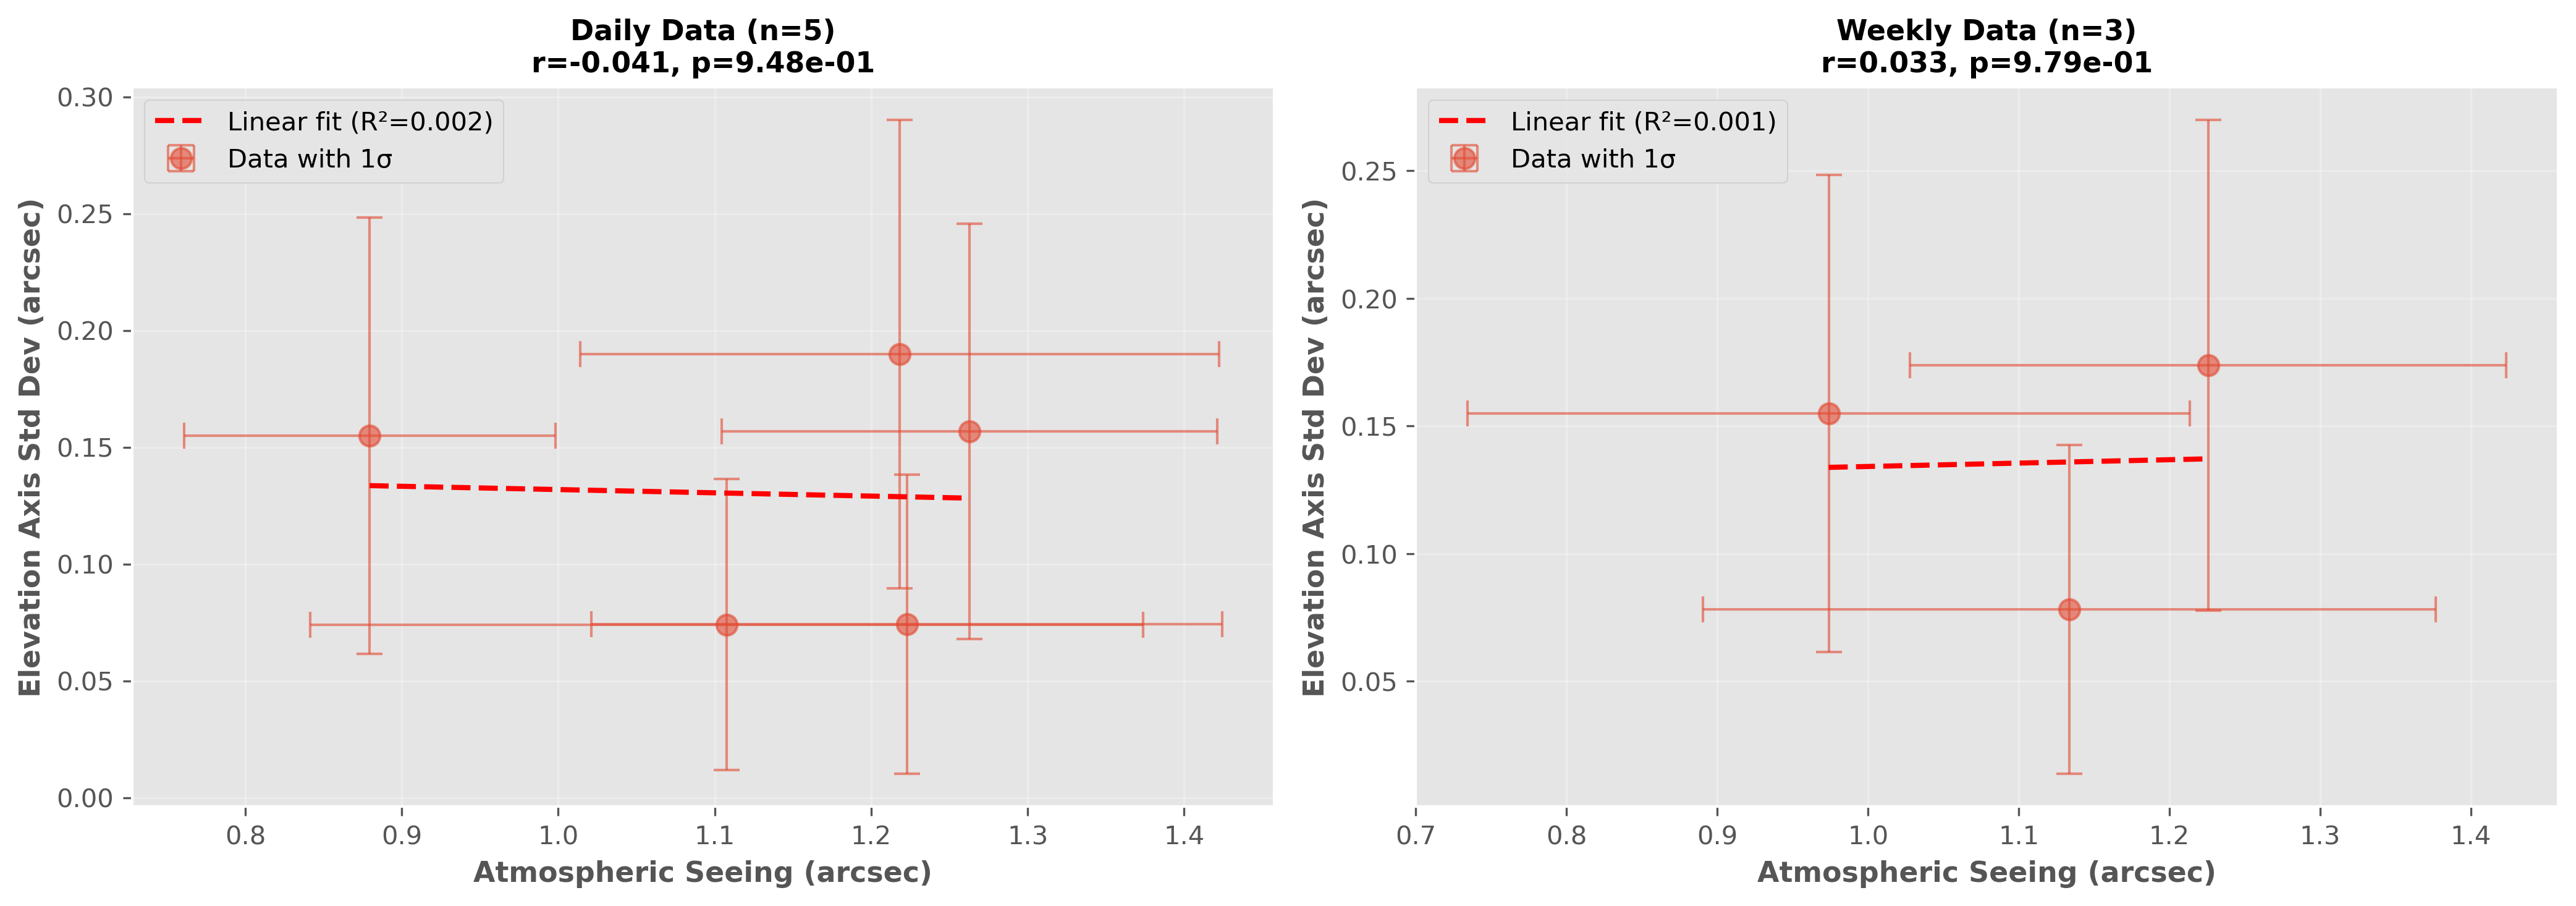

In [24]:
# Display the scatter plot
from IPython.display import Image, display

print("\n" + "="*60)
print("SCATTER PLOT: Daily/Weekly/Monthly Data with Regression Analysis")
print("="*60)
display(Image(filename='scatter_alt_vs_seeing.png'))


In [ ]:
# Section 7: Generate Time Series Visualization
# Create dual-axis time series plots showing trends over time

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily time series with dual axes
if df_daily is not None and len(df_daily) > 0:
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Plot elevation std on left axis (using correct column names)
    line1 = ax1.plot(df_daily.index, df_daily['alt_std_mean'], 'b-o', linewidth=2, markersize=6, label='Elevation Std Dev')
    ax1.fill_between(df_daily.index, 
                      df_daily['alt_std_mean'] - df_daily['alt_std_std'],
                      df_daily['alt_std_mean'] + df_daily['alt_std_std'],
                      alpha=0.2, color='blue', label='Std ±1σ')
    ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Elevation Std Dev (arcsec)', fontsize=11, fontweight='bold', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, alpha=0.3)
    
    # Plot seeing on right axis
    if 'seeing_mean' in df_daily.columns:
        line2 = ax1_twin.plot(df_daily.index, df_daily['seeing_mean'], 'r-o', linewidth=2, markersize=6, label='Atmospheric Seeing')
        ax1_twin.fill_between(df_daily.index,
                             df_daily['seeing_mean'] - df_daily['seeing_std'],
                             df_daily['seeing_mean'] + df_daily['seeing_std'],
                             alpha=0.2, color='red', label='Seeing ±1σ')
        ax1_twin.set_ylabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold', color='r')
        ax1_twin.tick_params(axis='y', labelcolor='r')
    
    ax1.set_title('Daily Trends: Elevation Axis Std Dev vs Atmospheric Seeing', 
                  fontsize=12, fontweight='bold')
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
else:
    axes[0].text(0.5, 0.5, 'No daily data available', ha='center', va='center', transform=axes[0].transAxes)

# Weekly time series
if df_weekly is not None and len(df_weekly) > 0:
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    line1 = ax2.plot(df_weekly.index, df_weekly['alt_std_mean'], 'b-o', linewidth=2, markersize=8, label='Elevation Std Dev')
    ax2.fill_between(df_weekly.index,
                     df_weekly['alt_std_mean'] - df_weekly['alt_std_std'],
                     df_weekly['alt_std_mean'] + df_weekly['alt_std_std'],
                     alpha=0.2, color='blue')
    ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Elevation Std Dev (arcsec)', fontsize=11, fontweight='bold', color='b')
    ax2.tick_params(axis='y', labelcolor='b')
    ax2.grid(True, alpha=0.3)
    
    if 'seeing_mean' in df_weekly.columns:
        line2 = ax2_twin.plot(df_weekly.index, df_weekly['seeing_mean'], 'r-o', linewidth=2, markersize=8, label='Atmospheric Seeing')
        ax2_twin.fill_between(df_weekly.index,
                             df_weekly['seeing_mean'] - df_weekly['seeing_std'],
                             df_weekly['seeing_mean'] + df_weekly['seeing_std'],
                             alpha=0.2, color='red')
        ax2_twin.set_ylabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold', color='r')
        ax2_twin.tick_params(axis='y', labelcolor='r')
    
    ax2.set_title('Weekly Trends: Elevation Axis Std Dev vs Atmospheric Seeing',
                  fontsize=12, fontweight='bold')
    
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'No weekly data available', ha='center', va='center', transform=axes[1].transAxes)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('timeseries_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Time series plot saved as 'timeseries_alt_vs_seeing.png'")

✓ Time series plot saved as 'timeseries_alt_vs_seeing.png'


/var/folders/p2/m7yvf3614rbcvdzvz6xh49c00000gn/T/ipykernel_58022/1411585849.py:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



TIME SERIES: Daily/Weekly Trends - Elevation vs Seeing


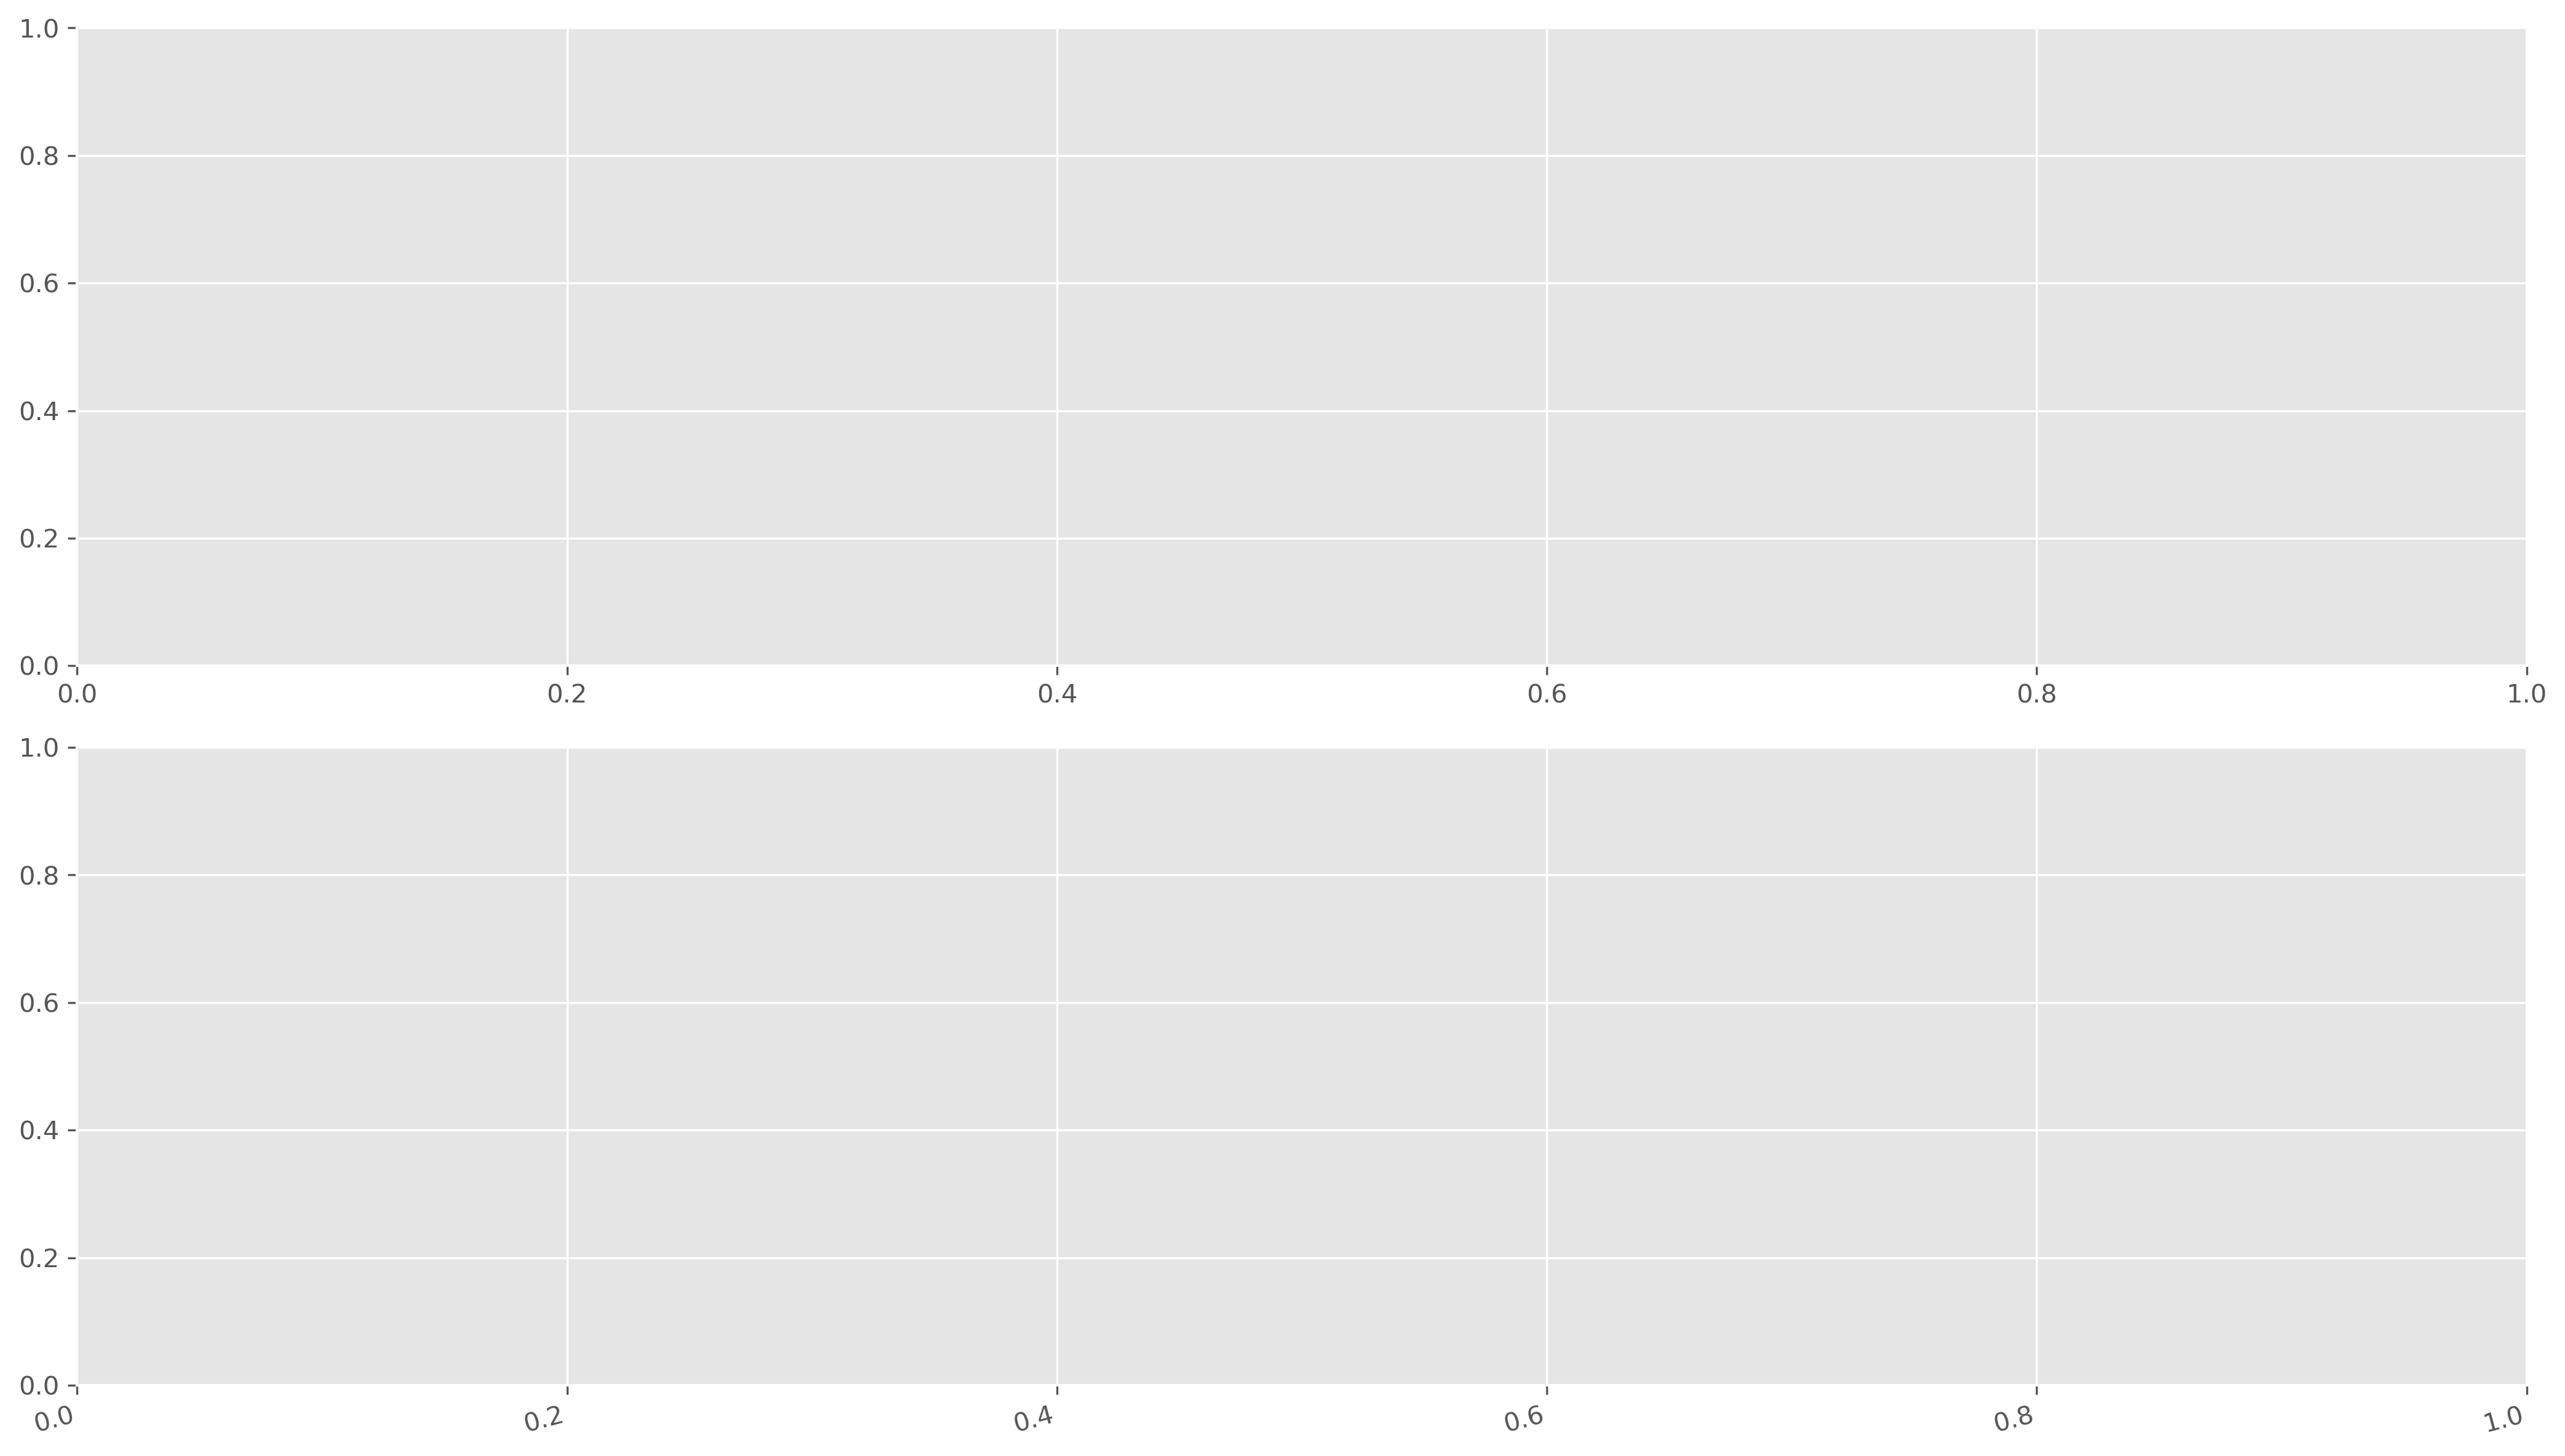

In [14]:
# Display the time series plot
print("\n" + "="*60)
print("TIME SERIES: Daily/Weekly Trends - Elevation vs Seeing")
print("="*60)
display(Image(filename='timeseries_alt_vs_seeing.png'))


In [15]:
# Section 8: Produce Hexbin Density Plot
# Hexbin visualization to show density distribution and identify clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resample_sets = [('Weekly', df_weekly), ('Monthly', df_monthly)]

for idx, (label, df) in enumerate(resample_sets):
    if df is not None and len(df) > 5:
        ax = axes[idx]
        
        x = df['seeing_mean'].values
        y = df['alt_rms_mean'].values
        
        # Remove NaN values
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 5:
            # Create hexbin plot
            hb = ax.hexbin(x, y, gridsize=8, cmap='YlOrRd', mincnt=1, edgecolors='black', linewidths=0.2)
            
            # Add regression line
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = slope * line_x + intercept
            ax.plot(line_x, line_y, 'b--', linewidth=2, label=f'Linear fit (R²={r_value**2:.3f})')
            
            ax.set_xlabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Elevation Axis RMS Error (arcsec)', fontsize=11, fontweight='bold')
            ax.set_title(f'{label} Data Density (n={len(x)})', fontsize=11, fontweight='bold')
            ax.legend(fontsize=10)
            
            # Colorbar
            cb = plt.colorbar(hb, ax=ax)
            cb.set_label('Count', fontsize=10)
            
            print(f"\n{label} Hexbin Statistics:")
            print(f"  Bins with data: {np.sum(hb.get_array() > 0)}")
            print(f"  Max count per bin: {np.max(hb.get_array())}")
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})',
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data available',
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('hexbin_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Hexbin density plot saved as 'hexbin_alt_vs_seeing.png'")


✓ Hexbin density plot saved as 'hexbin_alt_vs_seeing.png'


/var/folders/p2/m7yvf3614rbcvdzvz6xh49c00000gn/T/ipykernel_58022/45158474.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



HEXBIN DENSITY: Weekly/Monthly Data Distribution


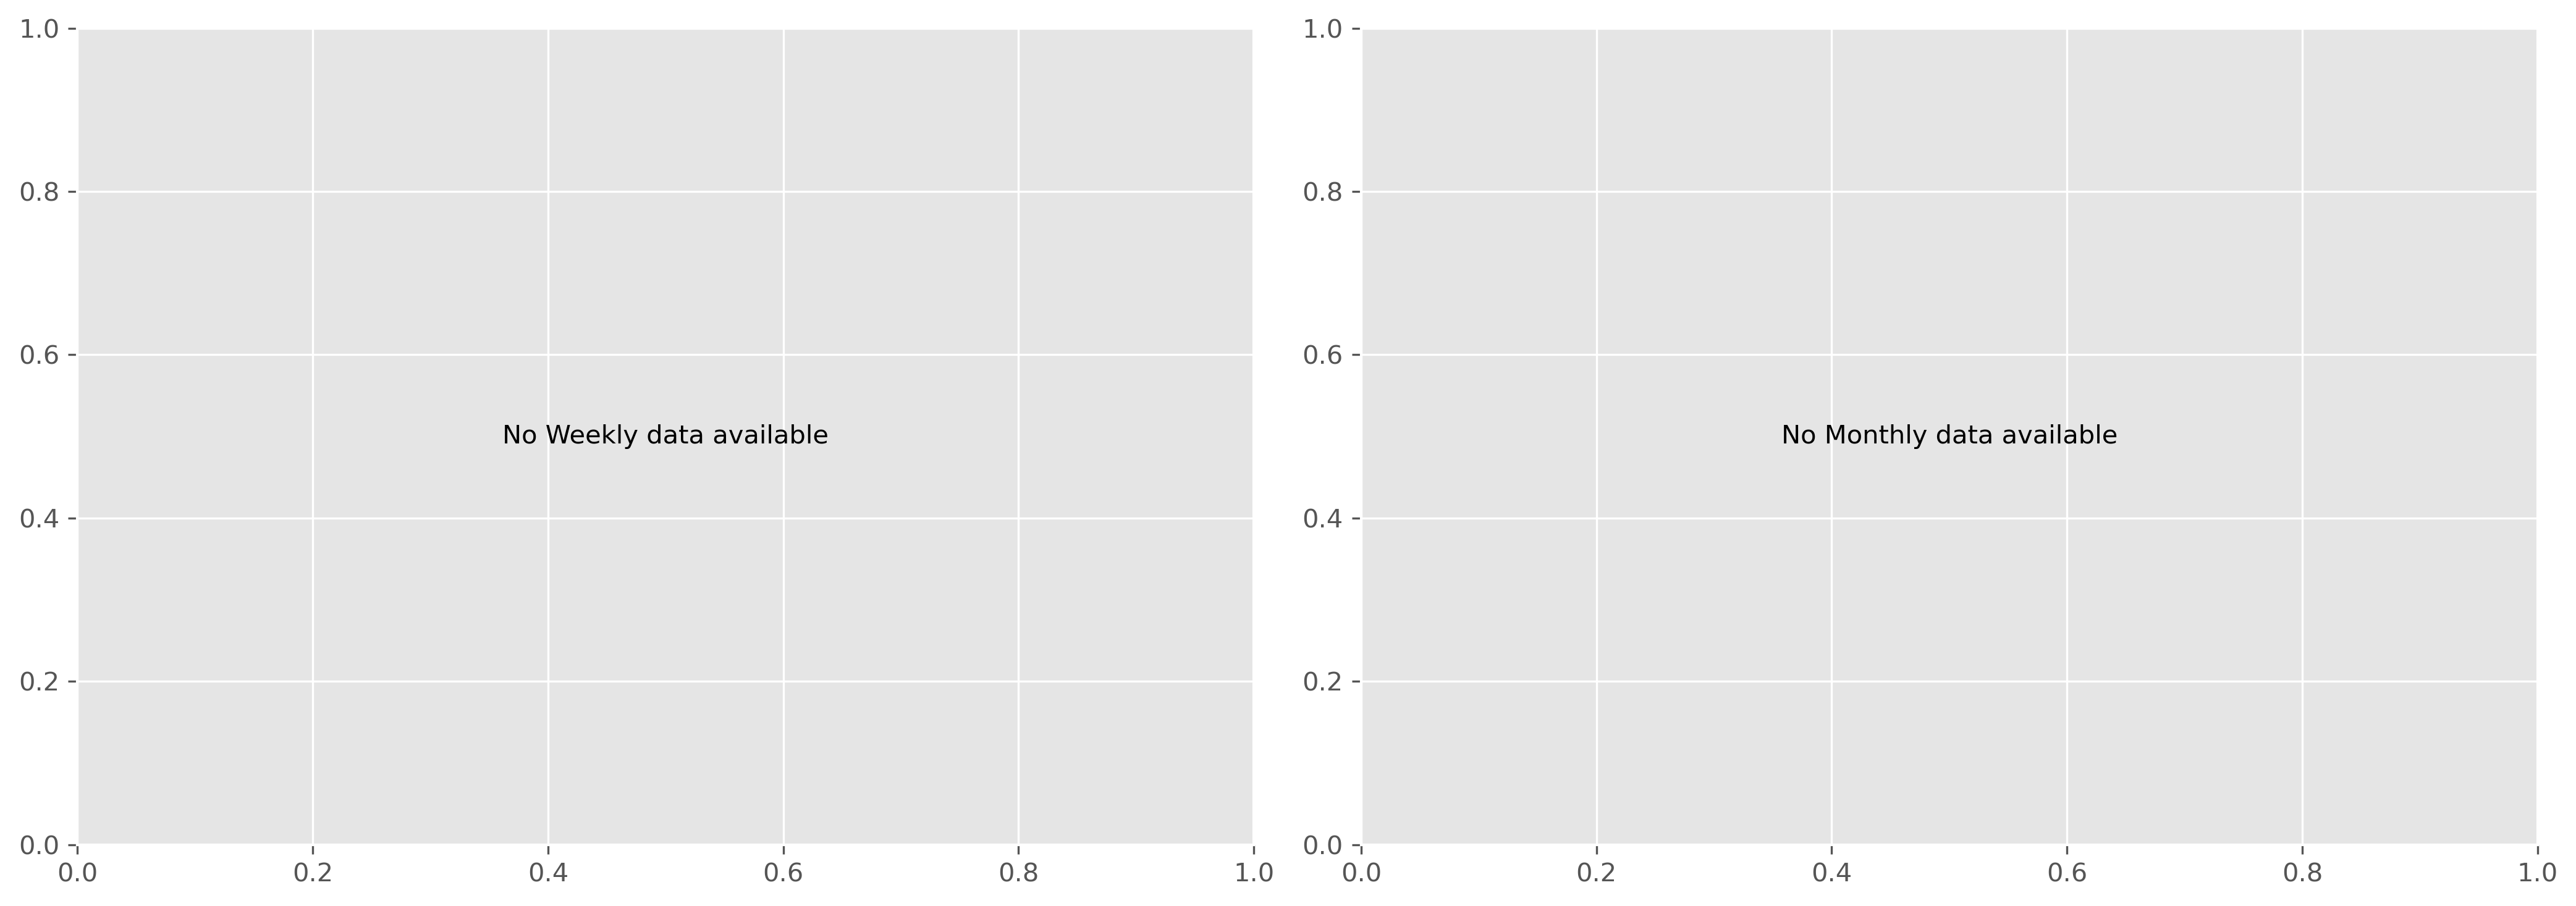

In [16]:
# Display the hexbin density plot
print("\n" + "="*60)
print("HEXBIN DENSITY: Weekly/Monthly Data Distribution")
print("="*60)
display(Image(filename='hexbin_alt_vs_seeing.png'))


## Recommendations for Optimal Data Presentation

### Best Practices for Visualizing Elevation Axis Performance vs Atmospheric Seeing

#### 1. **Primary Figure: Dual-Axis Time Series (Recommended for SPIE Paper)**
   - **Why it's best**: Shows temporal evolution of both parameters simultaneously
   - **Advantages**:
     - Reveals causality and response time (tracking error response to seeing changes)
     - Enables audience to correlate performance degradation with atmospheric conditions
     - Shows trends over extended observation periods
   - **Best practice**: Use weekly resampling for clarity without losing important variations
   - **Visual enhancement**: Use fill_between to show ±1σ uncertainty bands

#### 2. **Supporting Figure: Scatter Plot with Regression Analysis**
   - **Why include it**: Quantifies the linear relationship strength
   - **Key metrics to report**:
     - Correlation coefficient (r)
     - R² value (coefficient of determination)
     - P-value (statistical significance)
     - Slope (performance degradation rate per arcsec of seeing)
   - **Best resolution**: Weekly or monthly aggregation to reduce scatter
   - **Interpretation**: 
     - Strong correlation (r > 0.7) suggests atmospheric seeing is dominant factor
     - Weak correlation (r < 0.3) suggests other mechanical/control factors dominate

#### 3. **Supplementary Figure: Hexbin Density Plot**
   - **Why useful**: Reveals operational regimes and clustering
   - **Advantages**:
     - Identifies "sweet spots" where performance is optimal
     - Shows data concentration in parameter space
     - Highlights outliers or exceptional conditions
   - **Use case**: Technical audience or detailed analysis sections

#### 4. **Alternative: Contour Plot (Monthly Aggregation)**
   - **When to use**: If you have dense grid of data
   - **Advantages**: Shows smooth gradients in performance space
   - **Less recommended for**: Sparse or irregularly distributed data

### Specific Recommendations for SPIE 2026 Paper

**For Figure 1 (Main Results):**
- Use the **dual-axis weekly time series** showing 3-6 months of data
- Include clear labeling of extreme events (high seeing or poor tracking)
- Add annotation boxes highlighting key correlations or anomalies

**For Supporting Material:**
- Include the **scatter plot with statistics** showing correlation analysis
- Optional: Monthly-aggregated data for smoother trends

**Data Filtering Recommendations:**
- Exclude tracking data when telescope was slewing (not tracking)
- Filter seeing data: 0.2 - 3.0 arcsec (physical measurement limits)
- Minimum 5 observations per time bin (daily/weekly/monthly)
- Consider only "science" observation modes, exclude calibration data

### Key Metrics to Highlight

| Metric | Interpretation | Target |
|--------|---------------|----|
| **Correlation (r)** | Strength of seeing-performance link | > 0.5 for good correlation |
| **Slope** | arcsec error per arcsec seeing | Characteristic of servo system |
| **R²** | Fraction of variance explained by seeing | > 0.25 for meaningful relationship |
| **Baseline RMS** | Performance in excellent seeing | Design specification compliance |

### Color Scheme Recommendations
- **Elevation tracking error**: Blue (authority), consistent with technical plots
- **Seeing/atmospheric**: Red/orange (warning, external factor)
- **Confidence bands**: Lighter tints of corresponding colors
- **Regression line**: Contrasting color (dashed, for distinction from data)

In [17]:
# BONUS: 2D Kernel Density Estimation (Advanced Visualization)
# Creates smooth density contours for publication-quality figures

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resample_sets = [('Weekly', df_weekly, 8), ('Monthly', df_monthly, 5)]

for idx, (label, df, gridsize) in enumerate(resample_sets):
    if df is not None and len(df) > 10:
        ax = axes[idx]
        
        x = df['seeing_mean'].values
        y = df['alt_rms_mean'].values
        
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) > 10:
            # Compute 2D kernel density
            xy = np.vstack([x, y])
            z = gaussian_kde(xy)(xy)
            
            # Sort by density so densest points are plotted last
            idx_sort = np.argsort(z)
            x_sort, y_sort, z_sort = x[idx_sort], y[idx_sort], z[idx_sort]
            
            # Scatter plot colored by density
            scatter = ax.scatter(x_sort, y_sort, c=z_sort, s=60, cmap='viridis', 
                               edgecolors='k', linewidth=0.5, alpha=0.7)
            
            # Add regression line
            slope, intercept, r_value, _, _ = linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = slope * line_x + intercept
            ax.plot(line_x, line_y, 'r--', linewidth=2.5, label=f'Linear fit (R²={r_value**2:.3f})')
            
            ax.set_xlabel('Atmospheric Seeing (arcsec)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Elevation Axis RMS Error (arcsec)', fontsize=11, fontweight='bold')
            ax.set_title(f'{label} Data with Density (n={len(x)})', fontsize=11, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            
            cb = plt.colorbar(scatter, ax=ax)
            cb.set_label('Density', fontsize=10)
        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(x)})',
                   ha='center', va='center', transform=ax.transAxes)
    else:
        axes[idx].text(0.5, 0.5, f'No {label} data', ha='center', va='center',
                      transform=axes[idx].transAxes)

plt.tight_layout()
plt.savefig('kde_density_alt_vs_seeing.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 2D KDE density plot saved as 'kde_density_alt_vs_seeing.png'")

✓ 2D KDE density plot saved as 'kde_density_alt_vs_seeing.png'


/var/folders/p2/m7yvf3614rbcvdzvz6xh49c00000gn/T/ipykernel_58022/3530174069.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



2D KERNEL DENSITY ESTIMATION: Weekly/Monthly Data


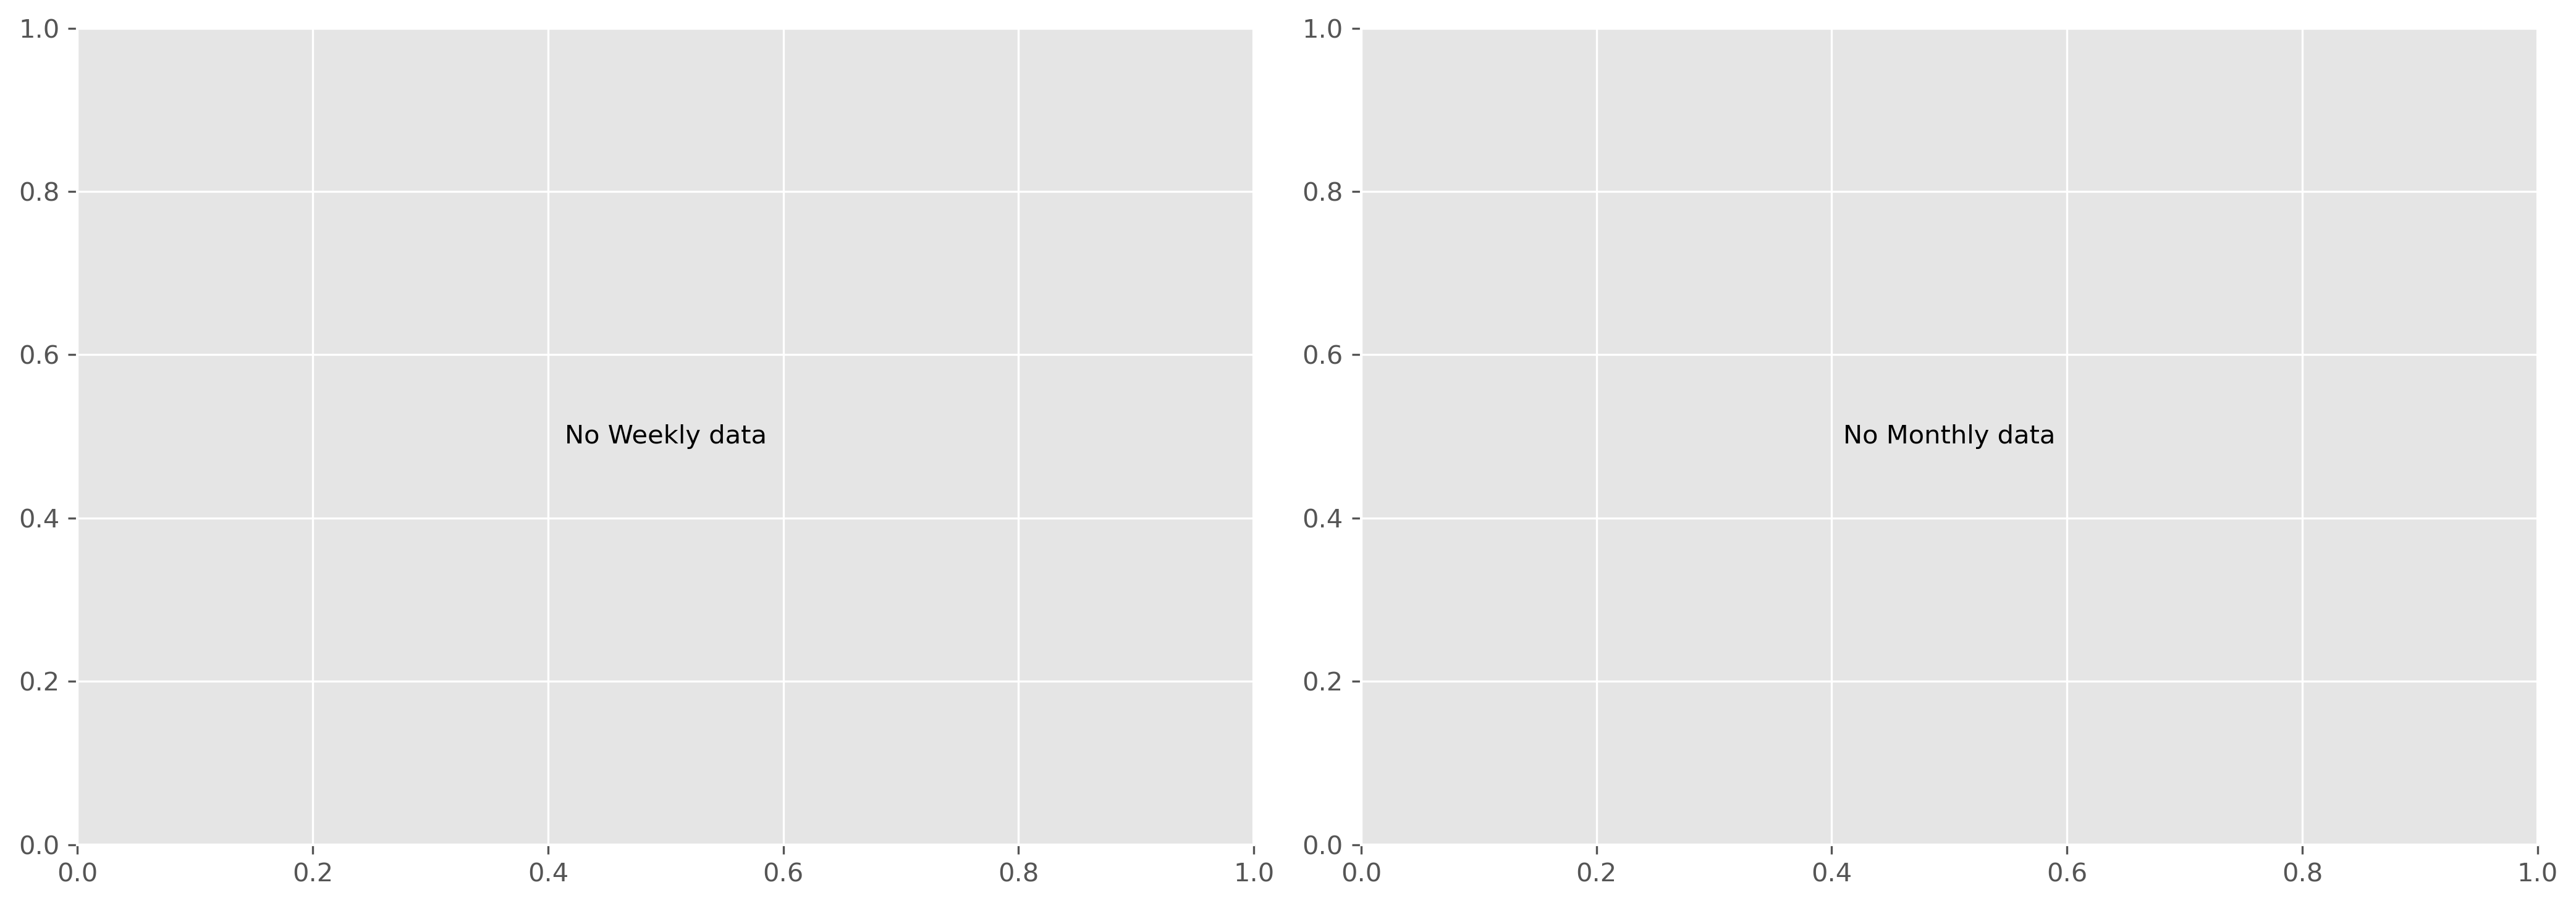

In [18]:
# Display the 2D KDE density plot
print("\n" + "="*60)
print("2D KERNEL DENSITY ESTIMATION: Weekly/Monthly Data")
print("="*60)
display(Image(filename='kde_density_alt_vs_seeing.png'))


## Summary: Figure Selection Guide for SPIE 2026 Paper

### Quick Reference Table

| Figure Type | Best For | Data Aggregation | Space Req'd | Impact |
|---|---|---|---|---|
| **Dual-Axis Time Series** | ⭐ PRIMARY | Weekly | 1 full page | High - Shows trends & correlation |
| **Scatter + Regression** | ⭐ SECONDARY | Monthly | 0.5 page | High - Quantifies relationship |
| **Hexbin Density** | Supporting | Weekly/Monthly | 0.5 page | Medium - Shows operational regimes |
| **2D KDE Contours** | Optional | Weekly/Monthly | 0.5 page | Medium - Publication quality |

### Implementation Checklist for Publication

- [ ] Extract last 6-12 months of:
  - Elevation axis RMS error (rd_stats table)
  - Atmospheric seeing measurements (WFS data)
  
- [ ] Apply quality filters:
  - Tracking mode only (exclude slewing)
  - Seeing range: 0.2-3.0 arcsec
  - Minimum 5 observations per time bin
  
- [ ] Generate visualizations:
  - [ ] Weekly time series (PRIMARY)
  - [ ] Monthly scatter plot (SECONDARY)
  - [ ] Optional: KDE density plot
  
- [ ] Calculate and report:
  - [ ] Pearson correlation coefficient
  - [ ] Linear regression slope & R²
  - [ ] P-value for statistical significance
  
- [ ] Document findings:
  - [ ] Performance baseline in excellent seeing
  - [ ] Performance degradation rate
  - [ ] Dominant factors limiting tracking

### Technical Notes

**For Python/Matplotlib Optimization:**
```python
# High-DPI figure for publication
plt.savefig('figure.png', dpi=300, bbox_inches='tight')

# Use seaborn for better defaults
sns.set_style("whitegrid")
sns.set_palette("husl")
```

**Database Query Optimization:**
- Index on (filename, param, MST_time) for rd_stats table
- Filter by time range in query (not in Python)
- Use `read_sql_query` with WHERE clauses for efficiency

**Statistical Considerations:**
- If r < 0.3: weak correlation suggests external factors dominate servo performance
- If r > 0.7: strong correlation suggests seeing is limiting factor
- Include confidence intervals (error bars) on all data points